## Sección 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import zipfile

# Cargar datos
with zipfile.ZipFile('../data/rt-iot2022.zip', 'r') as z:
    with z.open('RT_IOT2022') as f:
        df = pd.read_csv(f, index_col=0)

# Definir grupos de variables
iat_cols = [
    'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.avg', 'fwd_iat.std',
    'bwd_iat.min', 'bwd_iat.max', 'bwd_iat.tot', 'bwd_iat.avg', 'bwd_iat.std',
    'flow_iat.min', 'flow_iat.max', 'flow_iat.tot', 'flow_iat.avg', 'flow_iat.std',
]

payload_cols = [
    'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
    'fwd_pkts_payload.avg', 'fwd_pkts_payload.std',
    'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot',
    'bwd_pkts_payload.avg', 'bwd_pkts_payload.std',
    'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot',
    'flow_pkts_payload.avg', 'flow_pkts_payload.std',
]

all_cols = iat_cols + payload_cols

# Clasificación normal vs ataque (basada en docs/ataques.md)
normal_types = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
df['traffic'] = df['Attack_type'].apply(lambda x: 'Normal' if x in normal_types else 'Ataque')

# Paletas de color
palette_binary = {'Normal': 'steelblue', 'Ataque': 'tomato'}
attack_types   = df['Attack_type'].unique()
palette_tipo   = dict(zip(attack_types, sns.color_palette('tab20', n_colors=len(attack_types))))

# Conteo de muestras
counts = df['Attack_type'].value_counts()
print(df['traffic'].value_counts())
print()
print(counts)

traffic
Ataque    110610
Normal     12507
Name: count, dtype: int64

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


## Sección 1 — Estadísticas descriptivas

### 1.1 Resumen general

In [10]:
df[all_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
fwd_iat.min,123117.0,8843.27,1.226521e+06,0.0,0.00,0.00,0.00,3.002526e+08
fwd_iat.max,123117.0,1721565.57,9.229085e+06,0.0,0.00,0.00,0.00,3.002526e+08
fwd_iat.tot,123117.0,3780208.46,1.299675e+08,0.0,0.00,0.00,0.00,2.172834e+10
fwd_iat.avg,123117.0,237357.50,1.895354e+06,0.0,0.00,0.00,0.00,3.002526e+08
fwd_iat.std,123117.0,577557.39,3.204813e+06,0.0,0.00,0.00,0.00,2.122965e+08
bwd_iat.min,123117.0,3764.85,2.263147e+05,0.0,0.00,0.00,0.00,4.319622e+07
bwd_iat.max,123117.0,407726.69,4.288636e+06,0.0,0.00,0.00,0.00,3.000282e+08
bwd_iat.tot,123117.0,1779892.55,9.121196e+07,0.0,0.00,0.00,0.00,1.876117e+10
bwd_iat.avg,123117.0,87652.13,1.097456e+06,0.0,0.00,0.00,0.00,1.501489e+08
bwd_iat.std,123117.0,147480.26,1.784791e+06,0.0,0.00,0.00,0.00,2.119613e+08


### 1.2 Porcentaje de ceros por variable

In [12]:
zero_pct = (df[all_cols] == 0).mean() * 100
zero_pct.sort_values(ascending=False).rename('% ceros').to_frame()

,% ceros
bwd_pkts_payload.min,93.857063
bwd_iat.std,91.362688
fwd_pkts_payload.std,91.165314
fwd_iat.std,91.003679
bwd_pkts_payload.std,86.403990
bwd_iat.min,86.090467
bwd_iat.max,86.082344
bwd_iat.avg,86.082344
bwd_iat.tot,86.082344
bwd_pkts_payload.max,85.769634


### 1.3 Mediana por tipo de ataque

In [17]:
comp = df.groupby('traffic')[all_cols].median().T.round(2)
comp.columns = ['Ataque', 'Normal']
comp['ratio Ataque/Normal'] = (comp['Ataque'] / comp['Normal'].replace(0, np.nan)).round(2)
comp.sort_values('ratio Ataque/Normal', ascending=False)

,Ataque,Normal,ratio Ataque/Normal
flow_pkts_payload.std,84.85,16.00,5.30
fwd_pkts_payload.avg,120.00,30.71,3.91
fwd_pkts_payload.max,120.00,36.00,3.33
flow_pkts_payload.max,120.00,68.00,1.76
fwd_pkts_payload.tot,120.00,78.00,1.54
flow_pkts_payload.avg,60.00,44.00,1.36
flow_pkts_payload.tot,120.00,176.00,0.68
flow_iat.min,3.81,183.11,0.02
fwd_iat.tot,0.00,881945.85,0.00
fwd_iat.max,0.00,294732.09,0.00


## Sección 2 — Distribuciones (small multiples)

### 2.1 Distribución de las variables — comparación binaria


=== Payload ===

=== IAT ===


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3825821431.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)


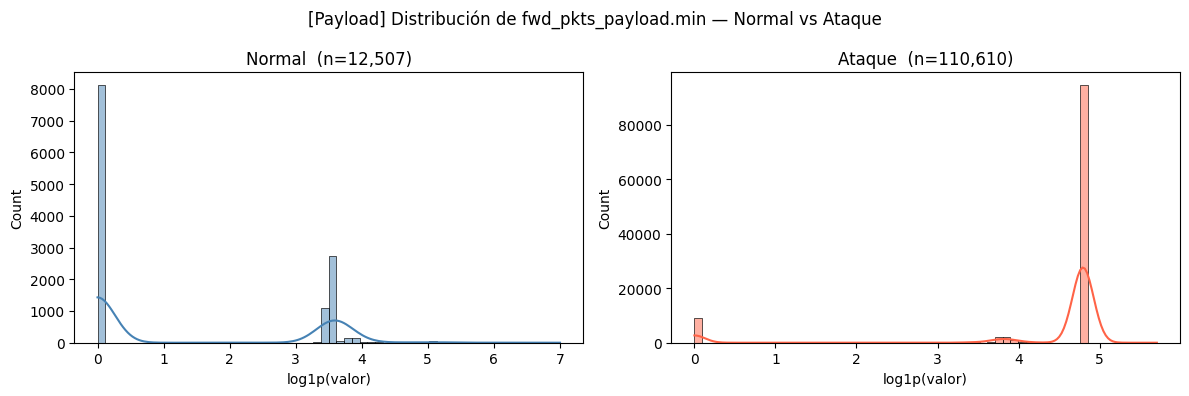

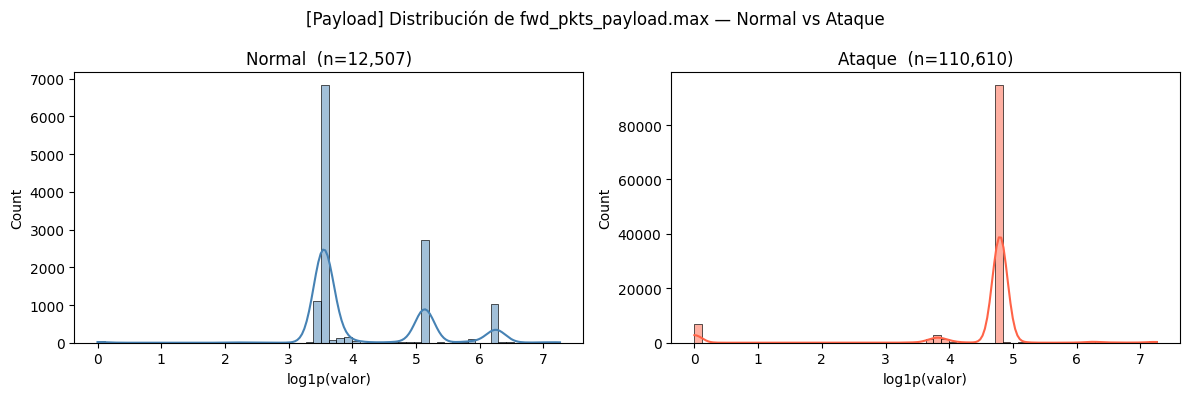

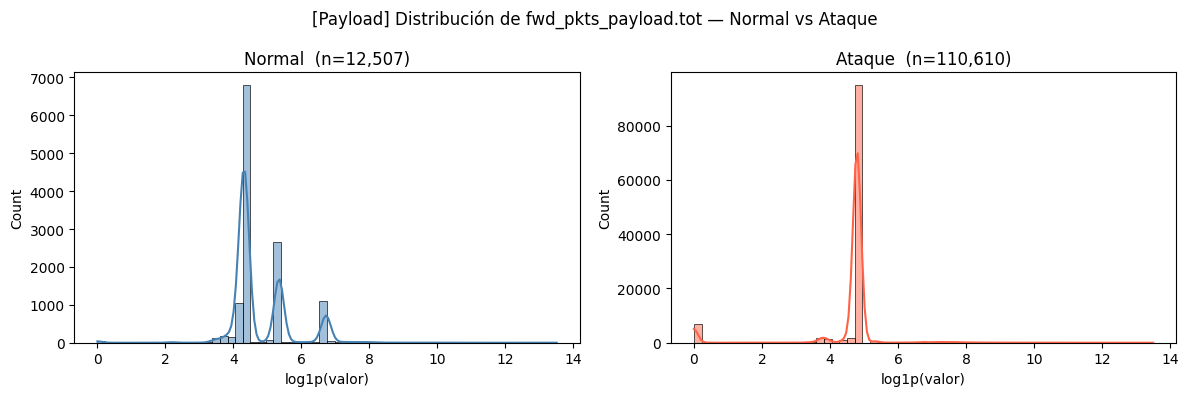

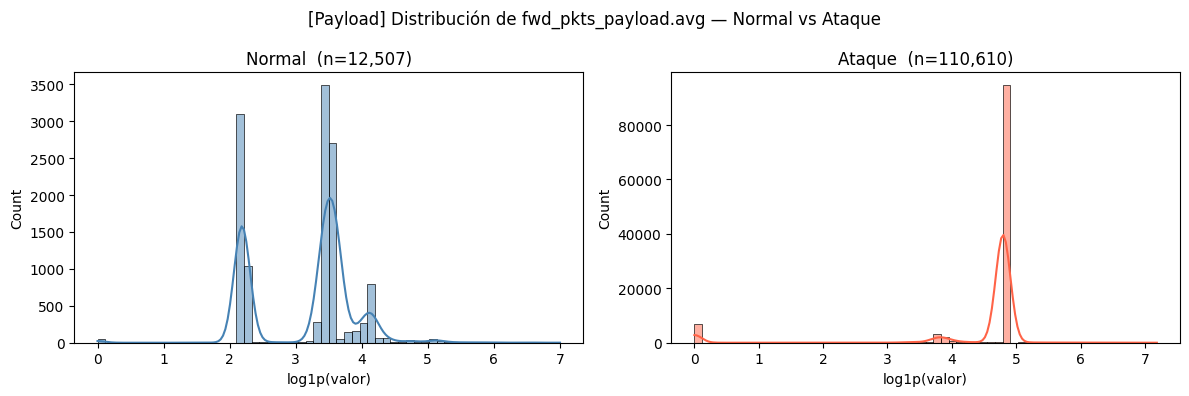

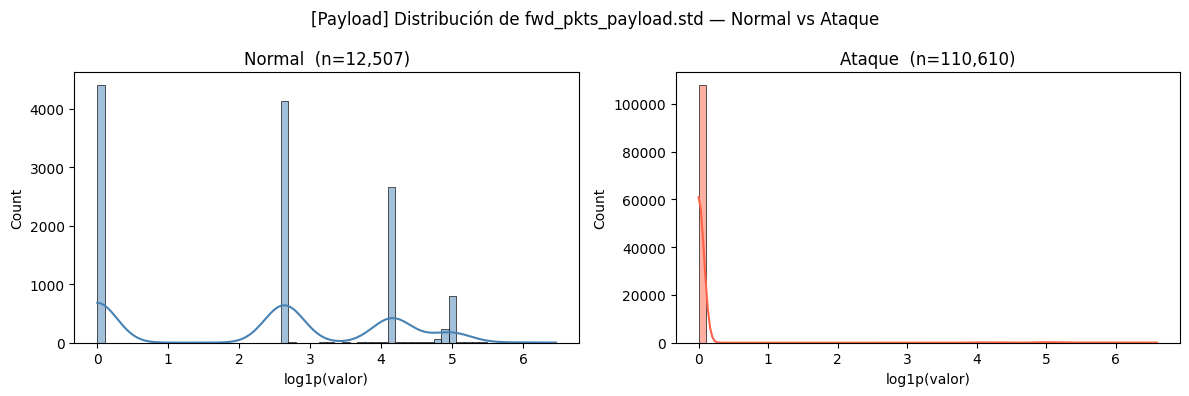

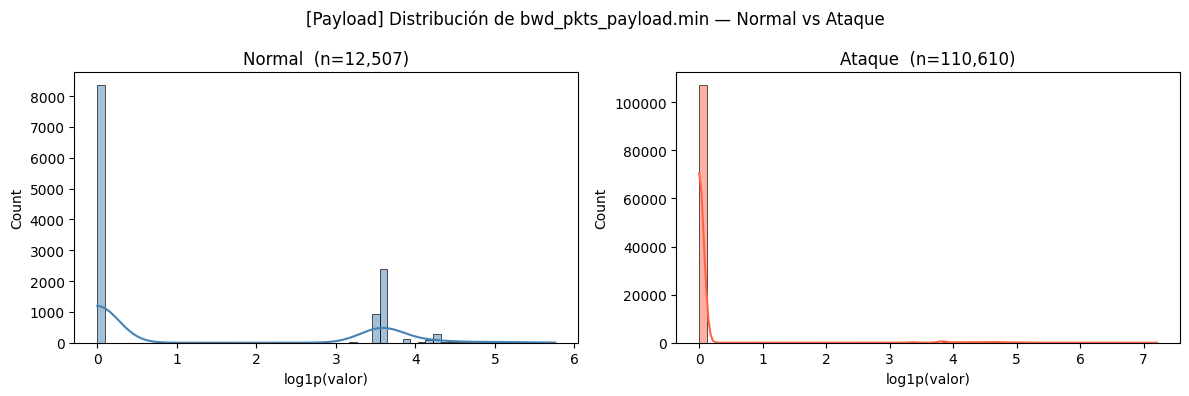

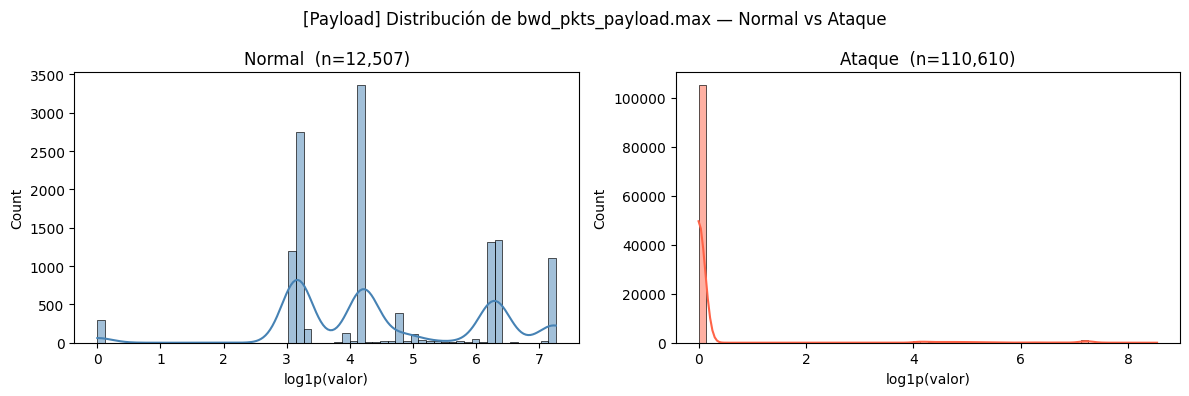

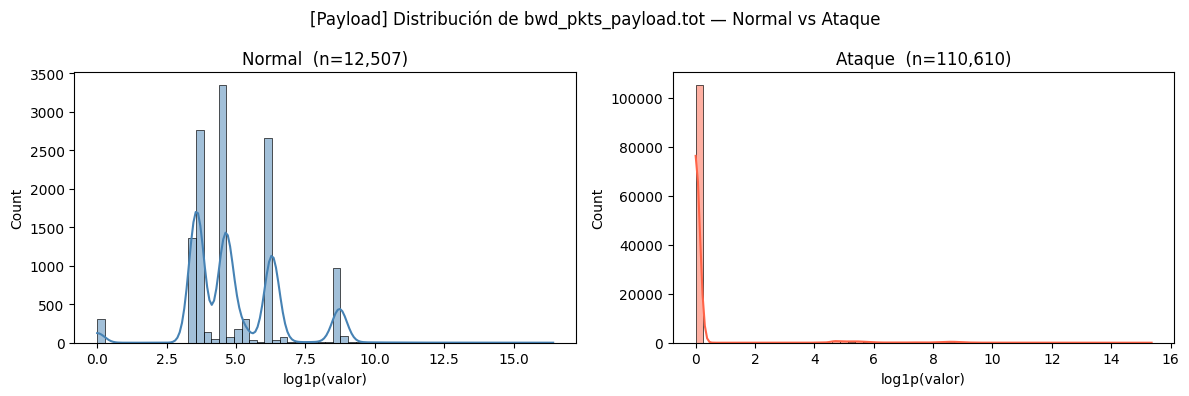

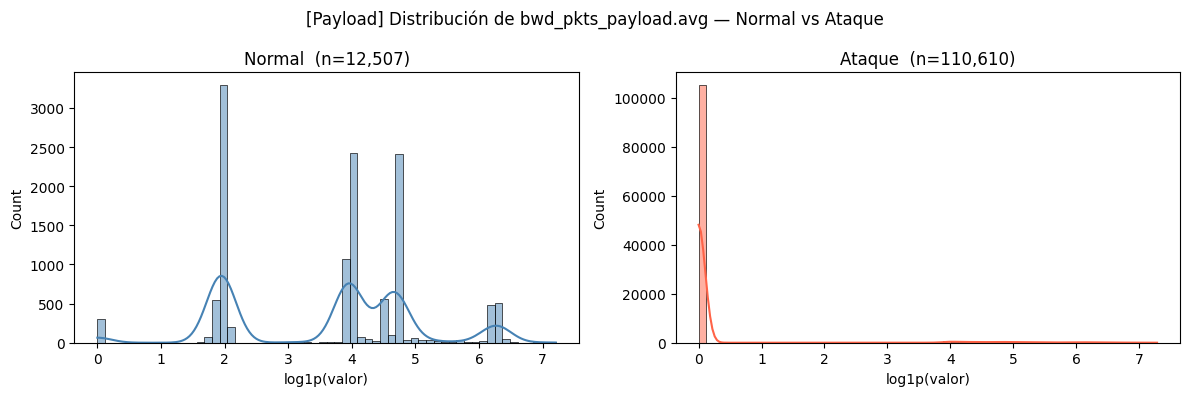

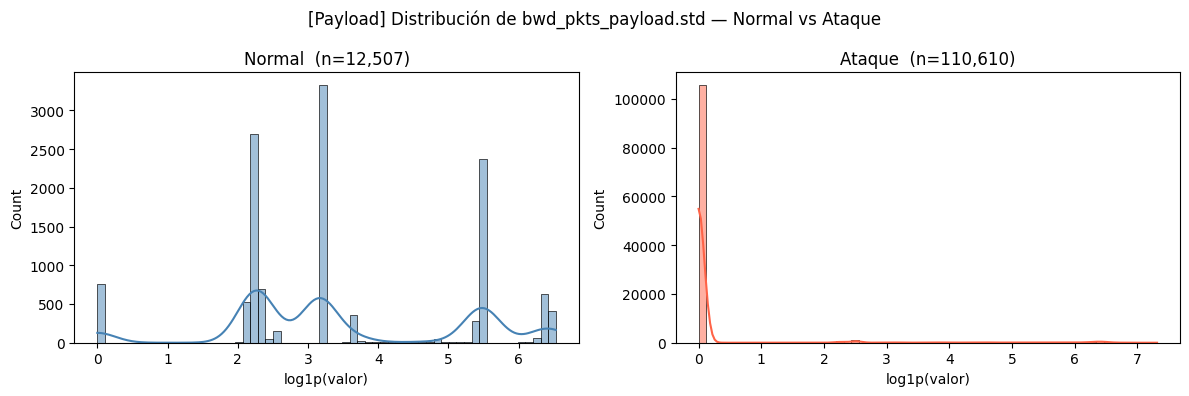

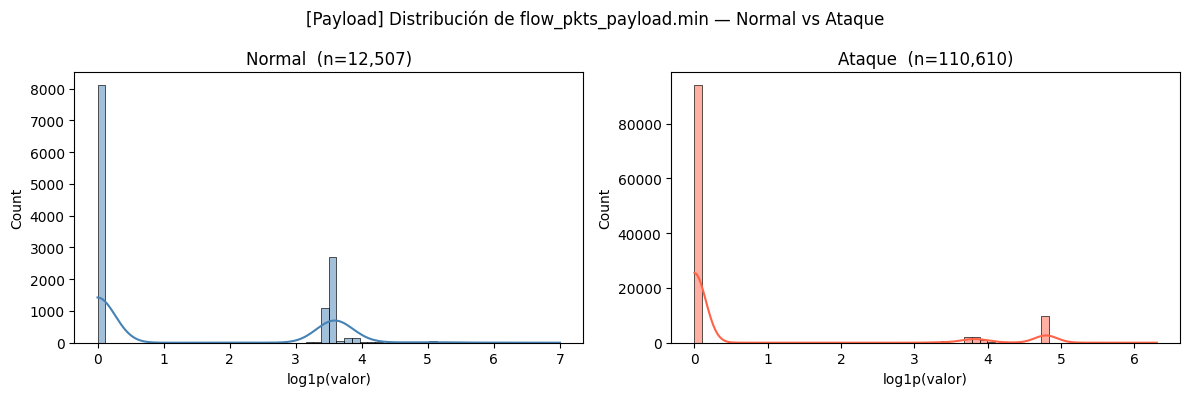

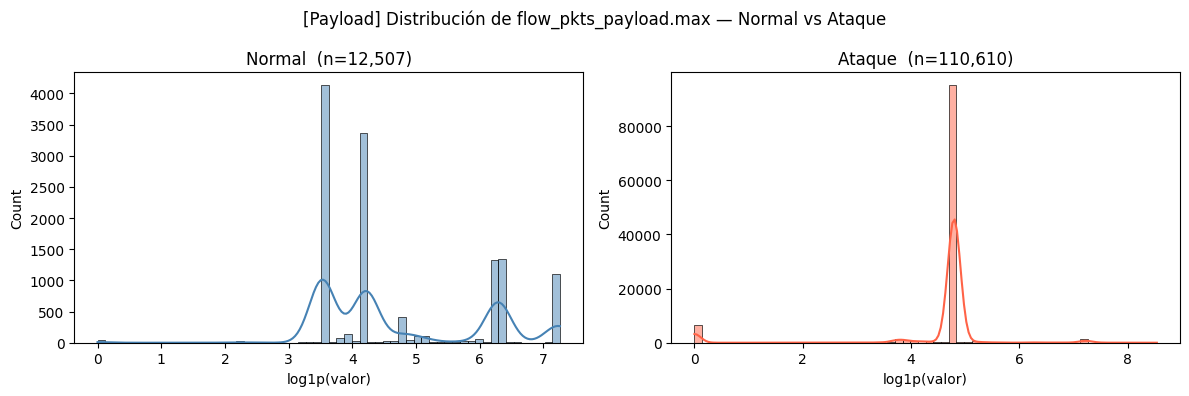

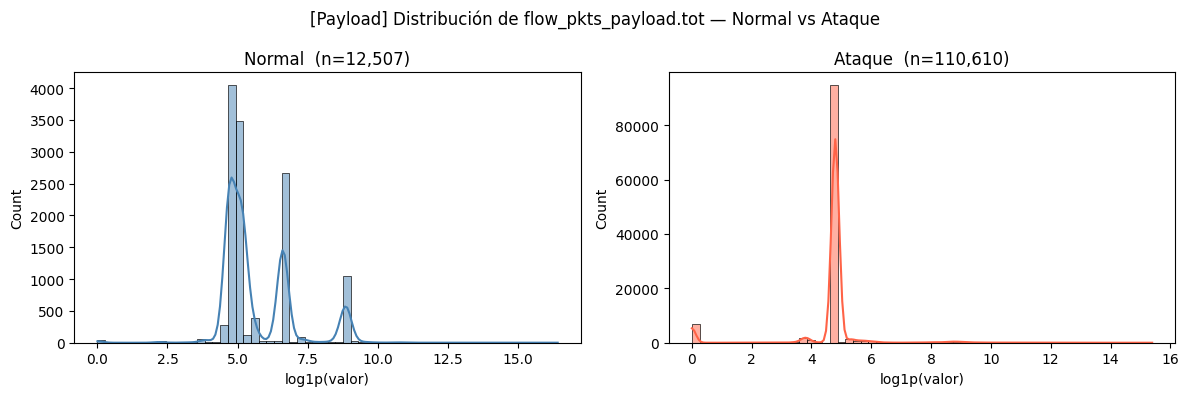

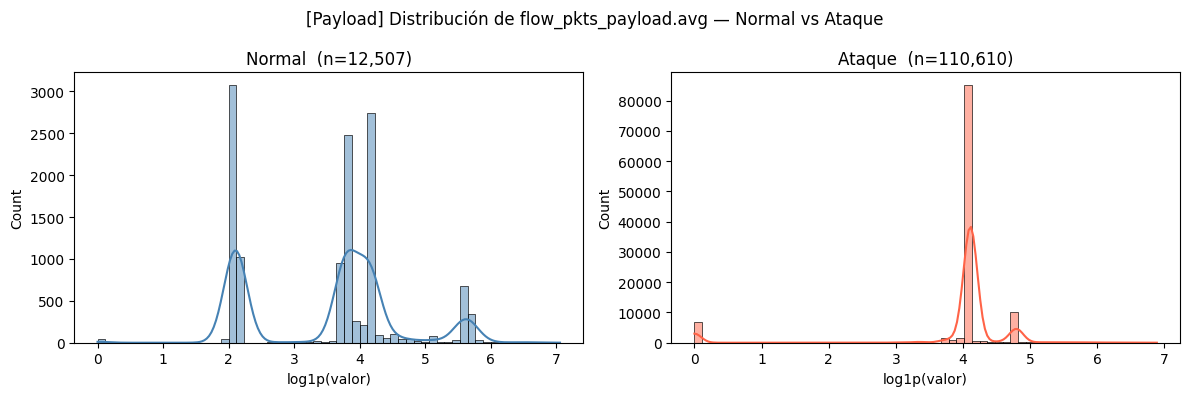

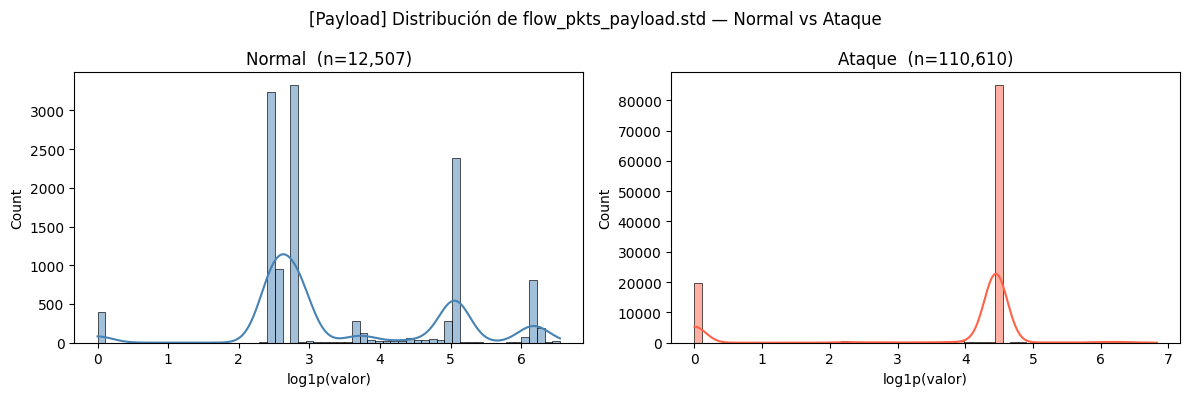

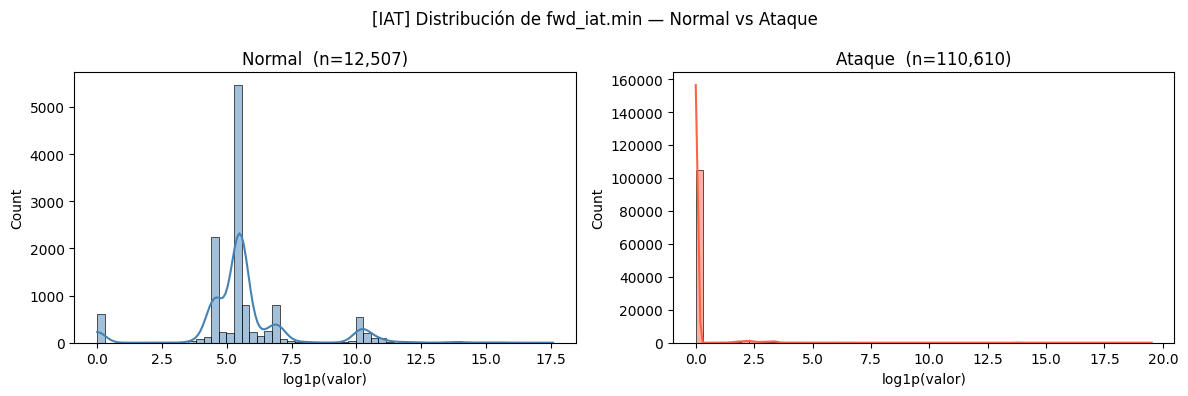

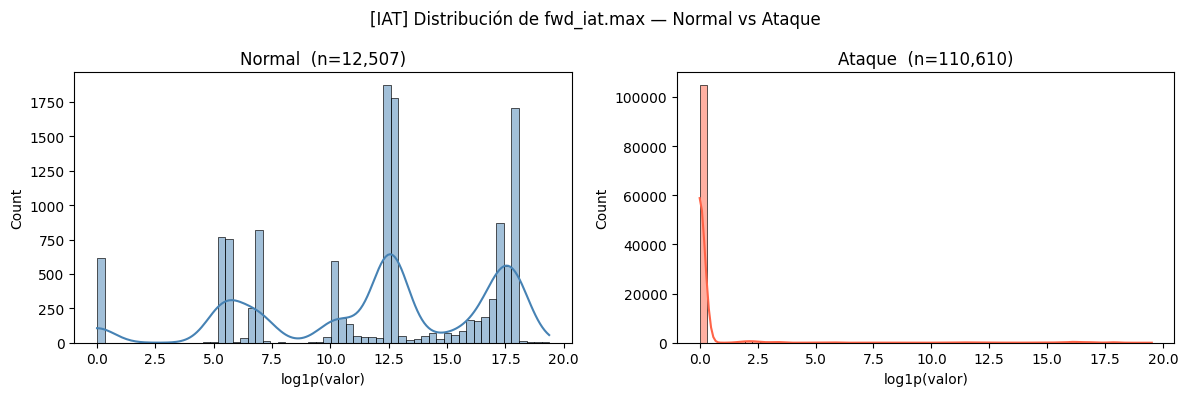

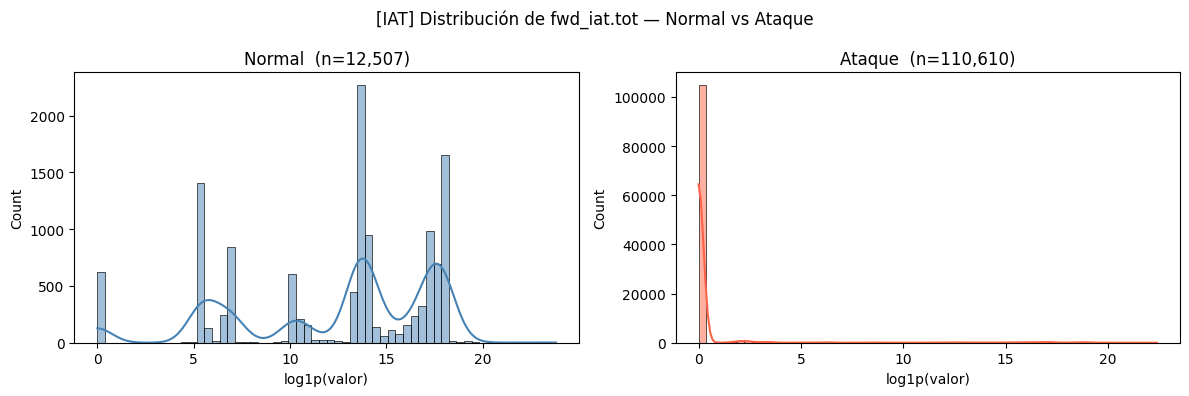

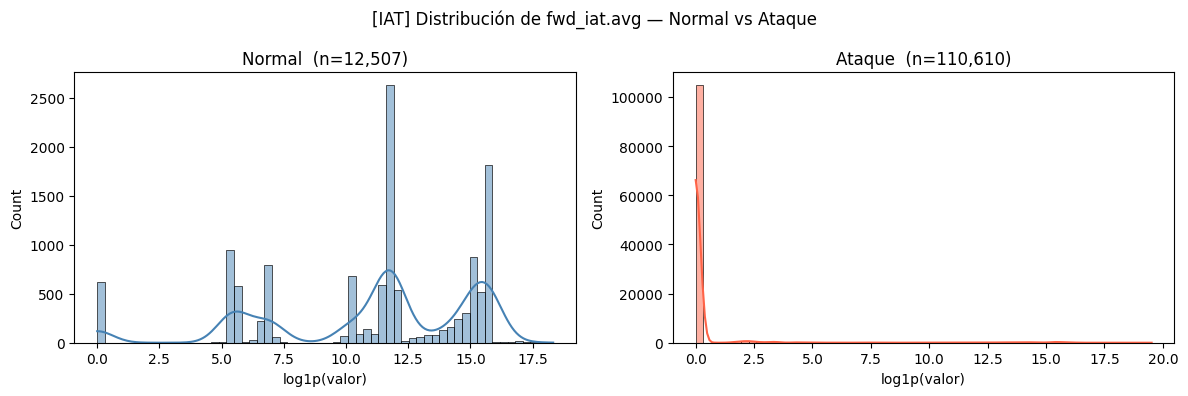

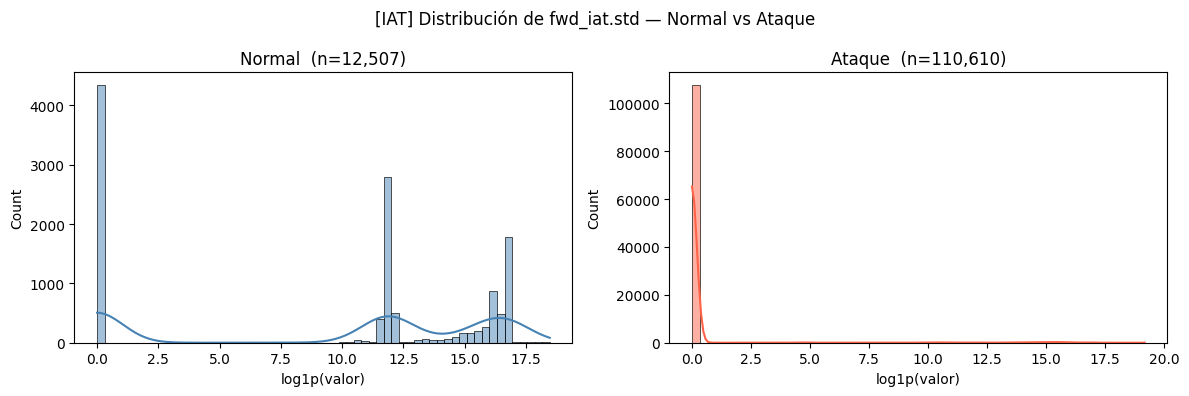

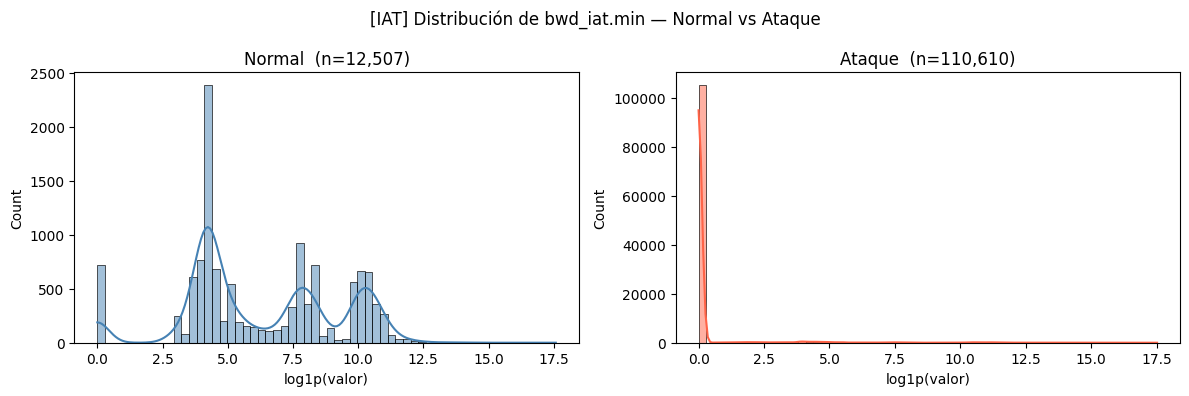

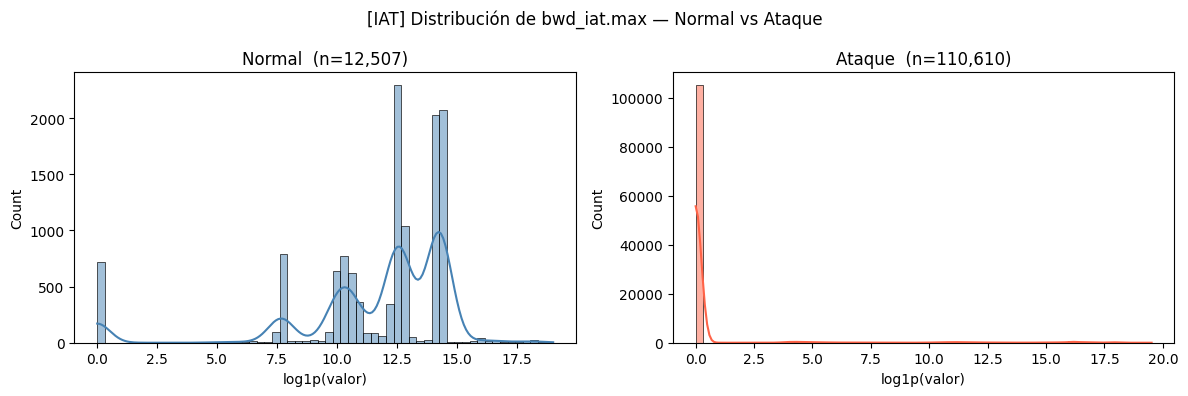

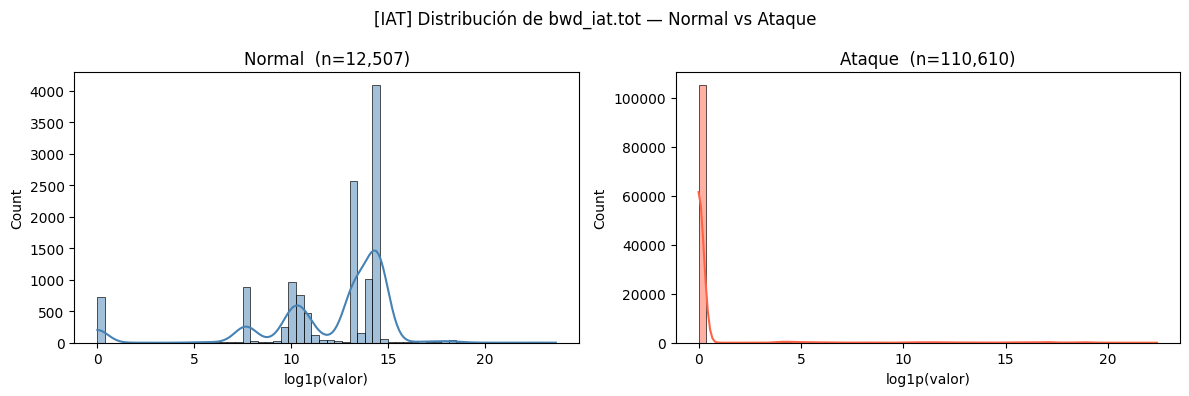

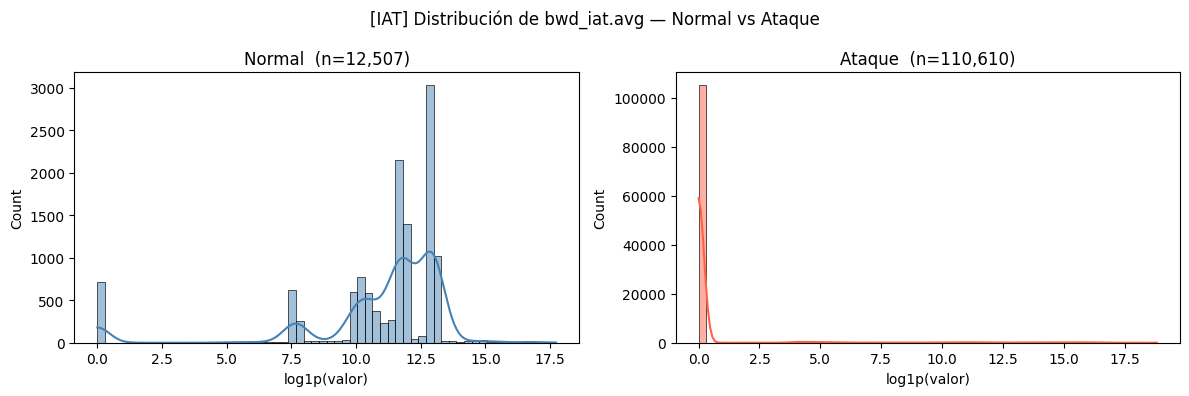

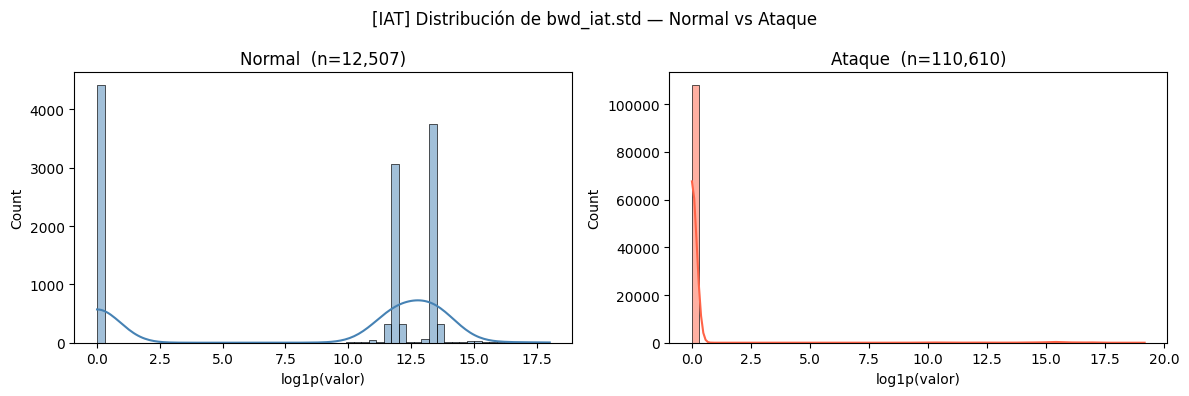

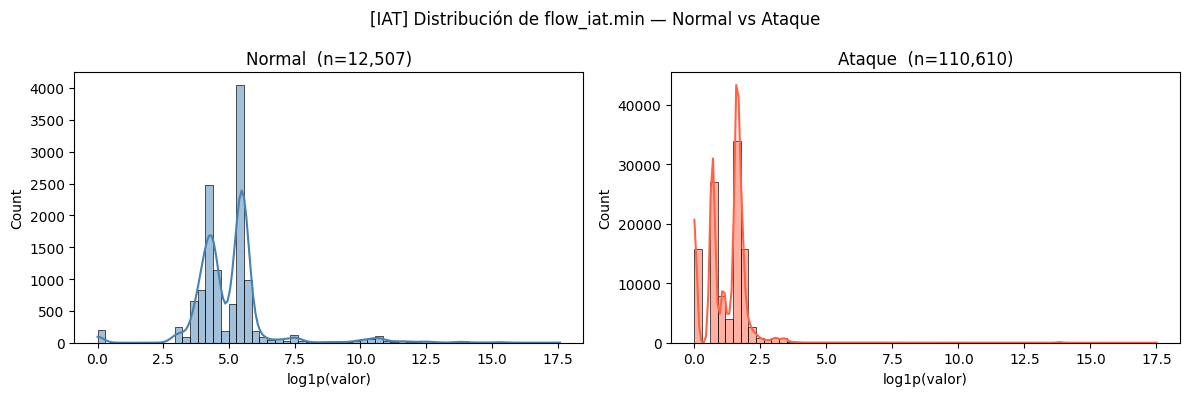

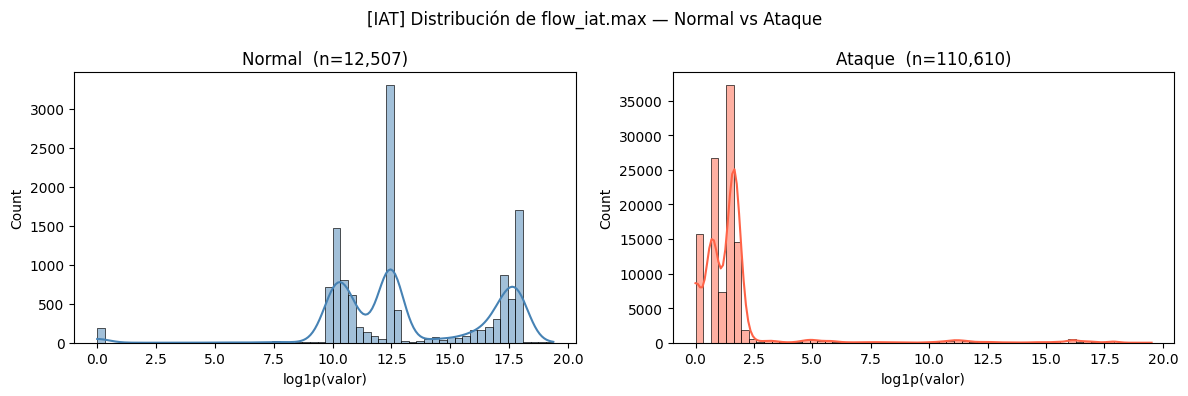

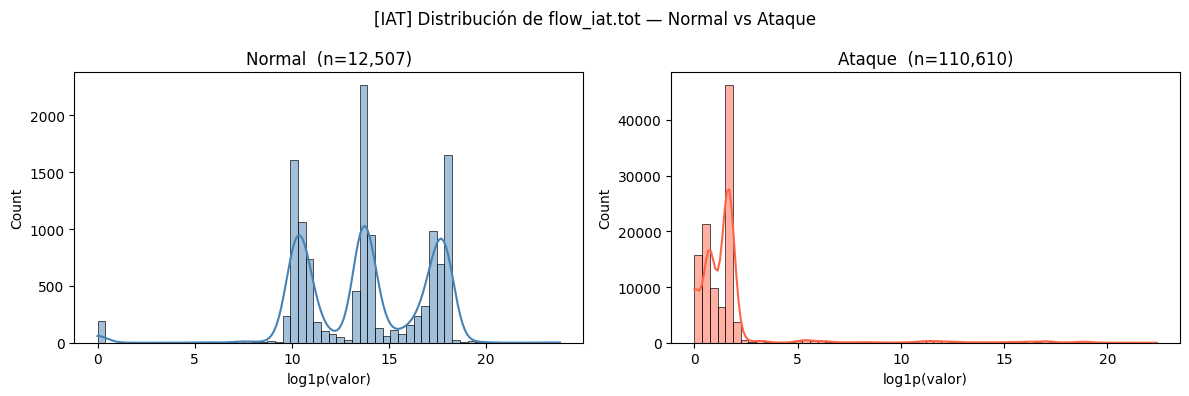

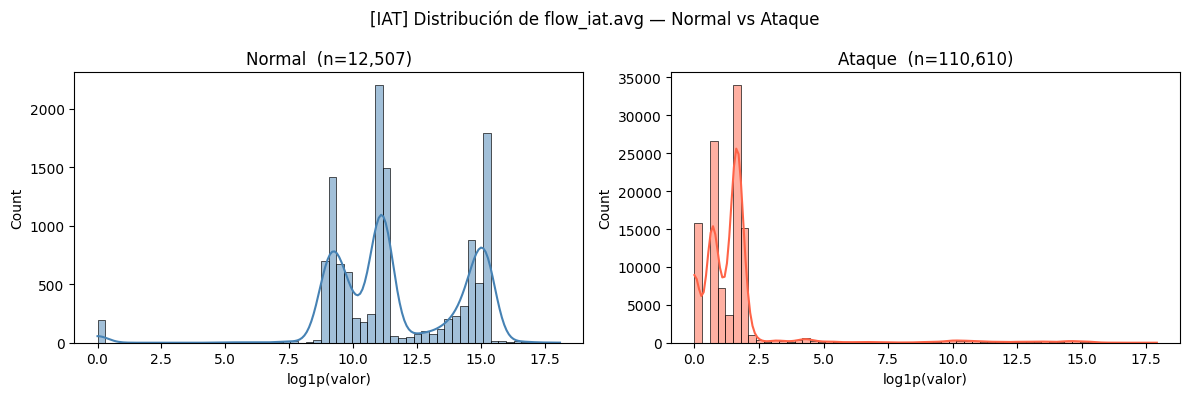

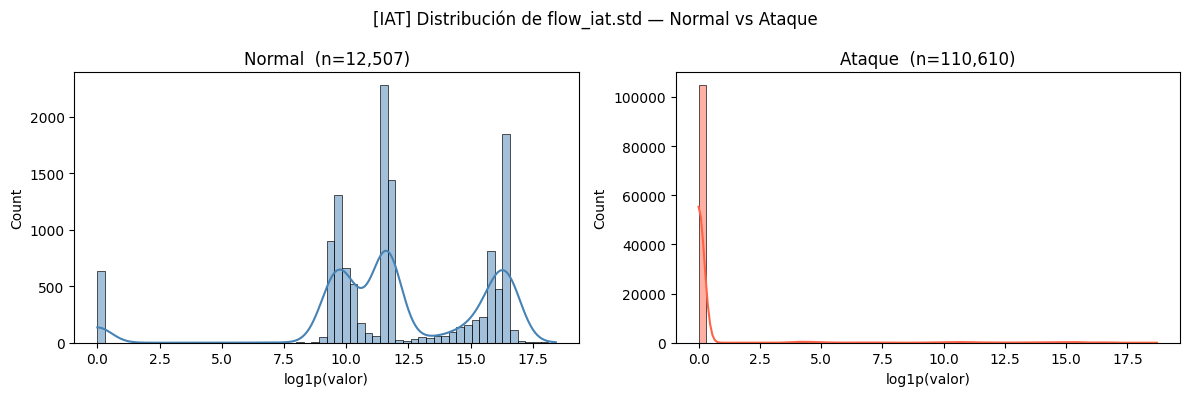

In [13]:
for nombre_grupo, lista_cols in [('Payload', payload_cols), ('IAT', iat_cols)]:
     print(f'\n=== {nombre_grupo} ===')
     for col in lista_cols:
         fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
         for ax, grupo in zip(axes, ['Normal', 'Ataque']):
             vals = np.log1p(df[df['traffic'] == grupo][col].clip(lower=0))
             sns.histplot(vals, ax=ax, color=palette_binary[grupo], bins=60, kde=True)
             ax.set_title(f'{grupo}  (n={len(vals):,})')
             ax.set_xlabel('log1p(valor)')
         plt.suptitle(f'[{nombre_grupo}] Distribución de {col} — Normal vs Ataque', fontsize=12)
         plt.tight_layout()

### 2.2 Distribución de las variables — comparación binaria y por tipo

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fil

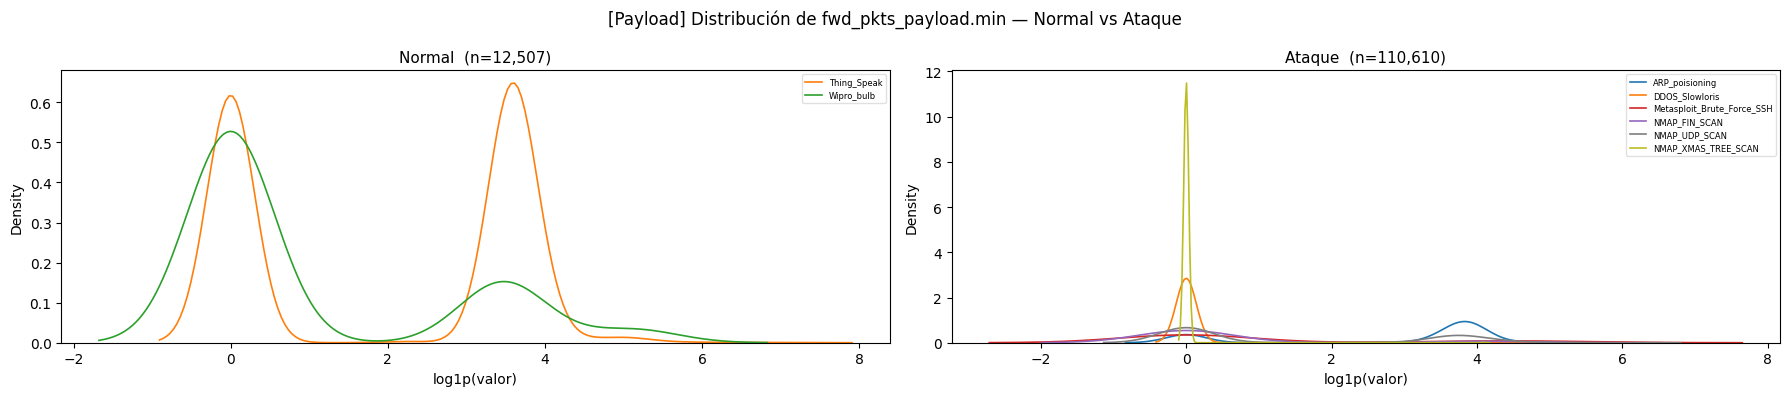

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


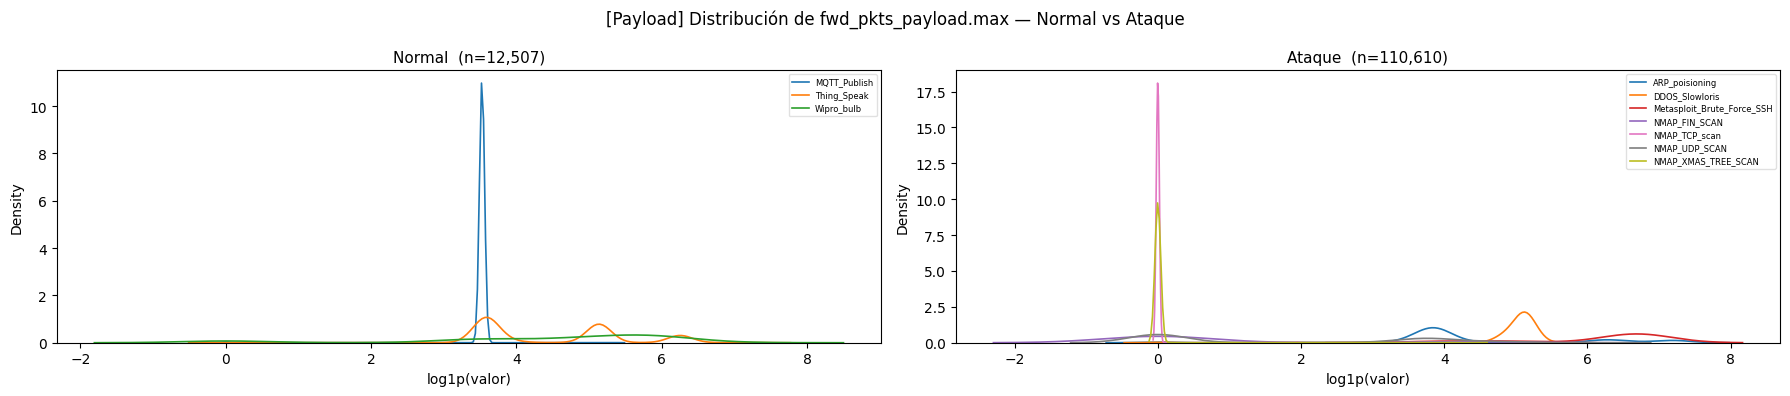

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


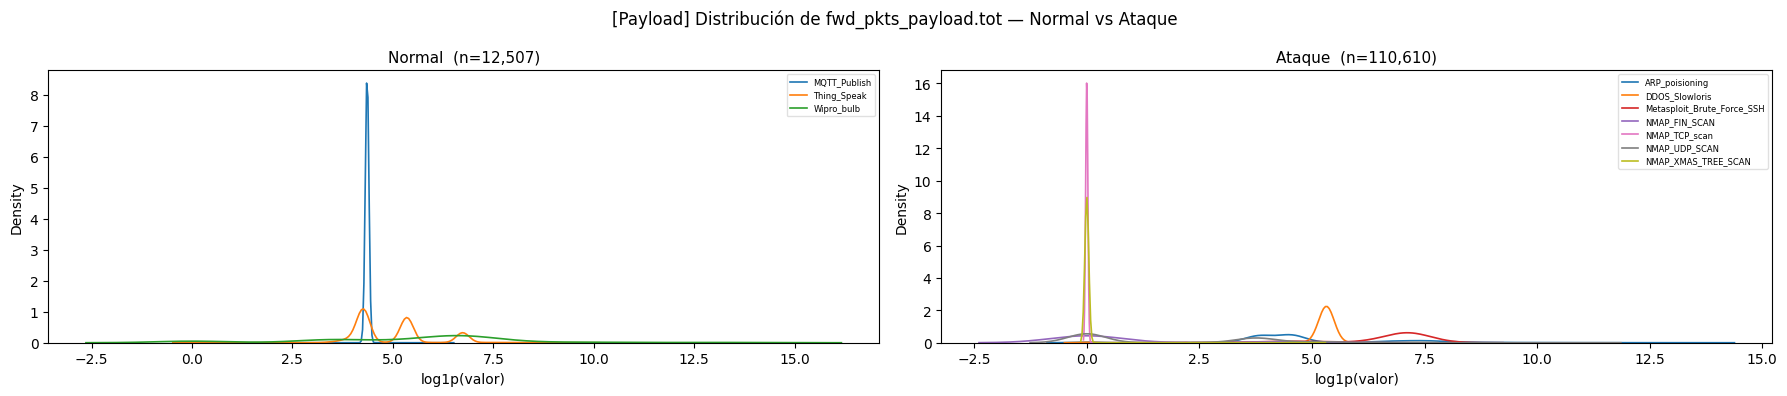

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


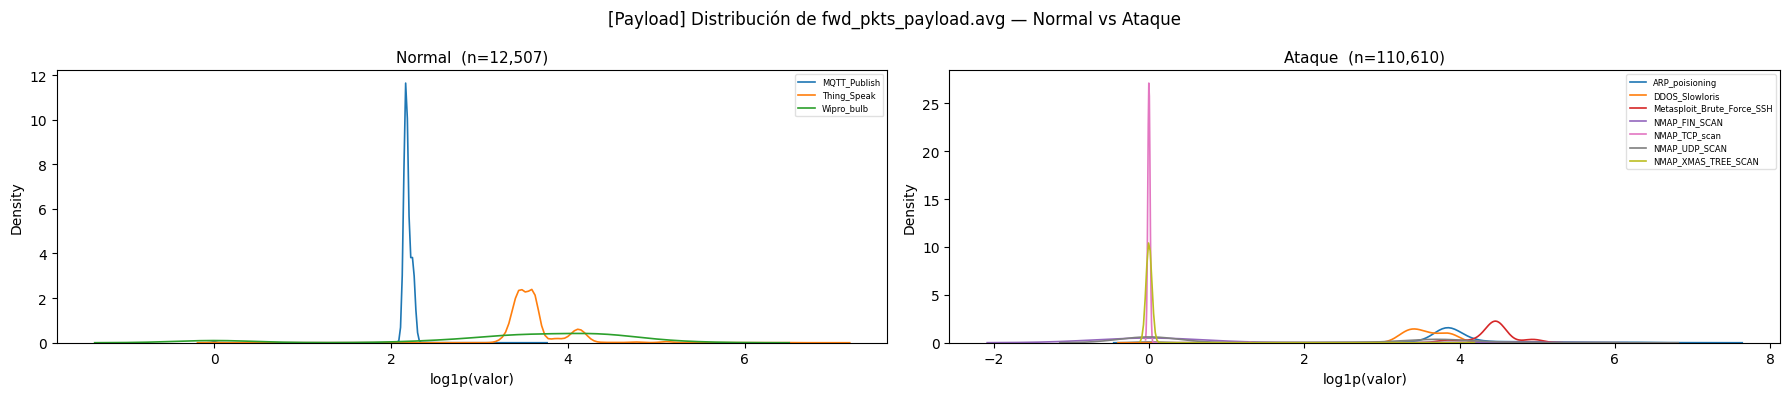

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


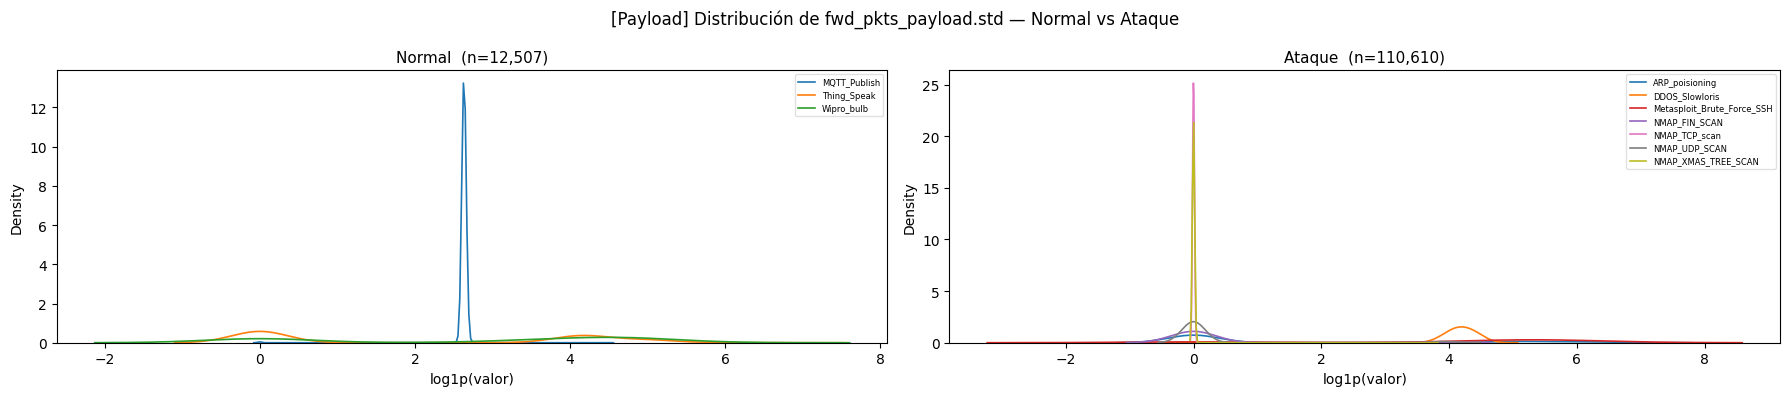

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fil

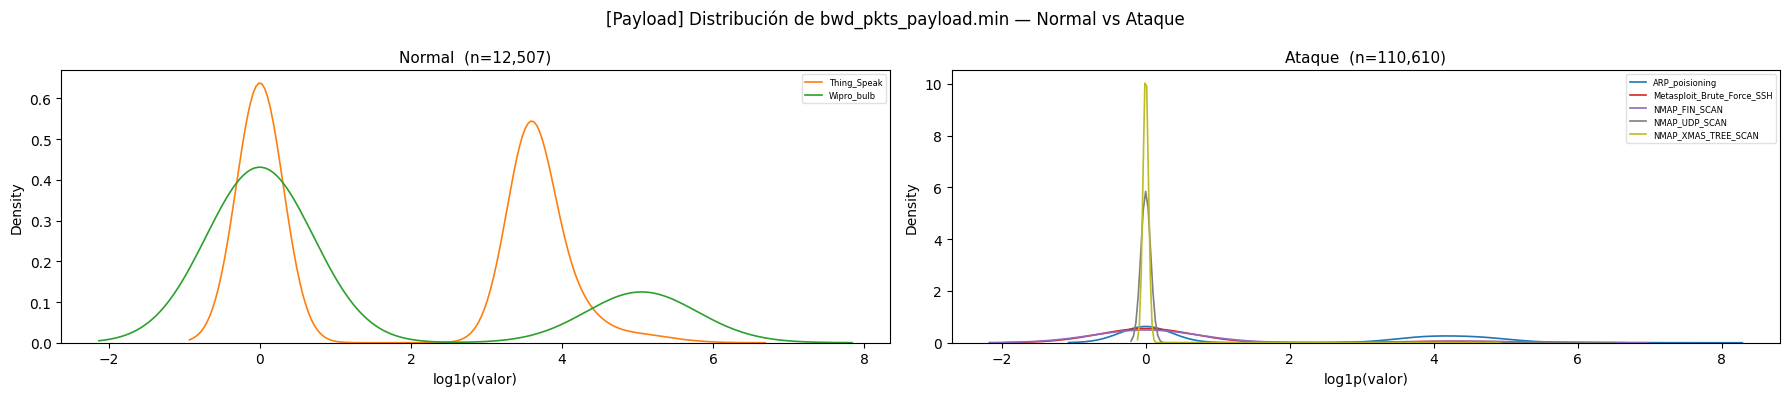

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


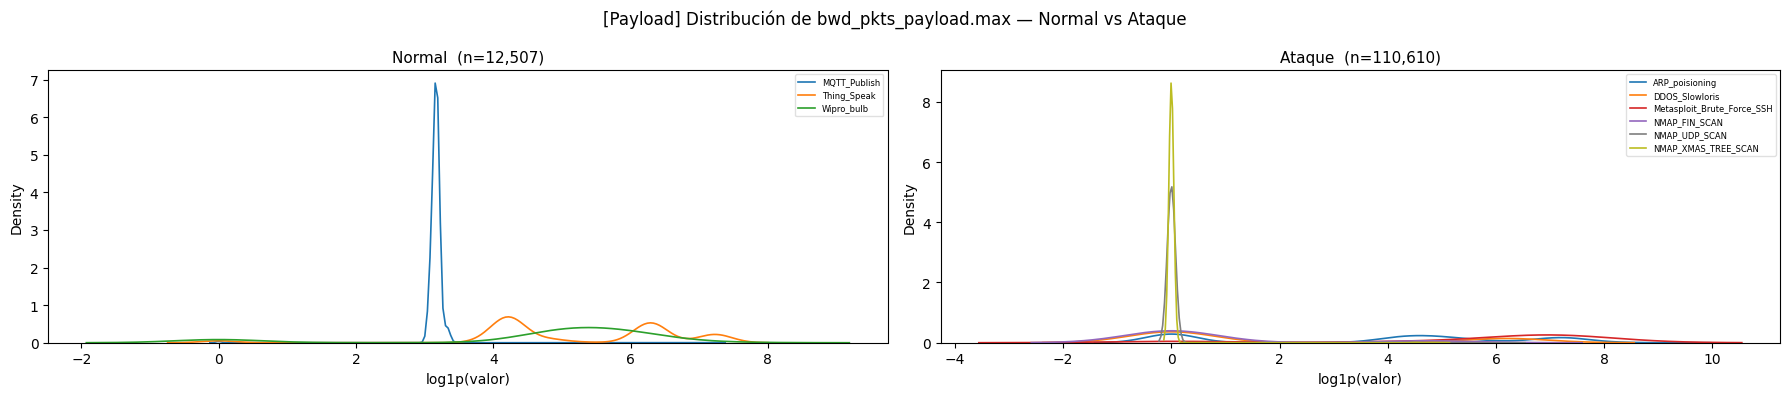

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


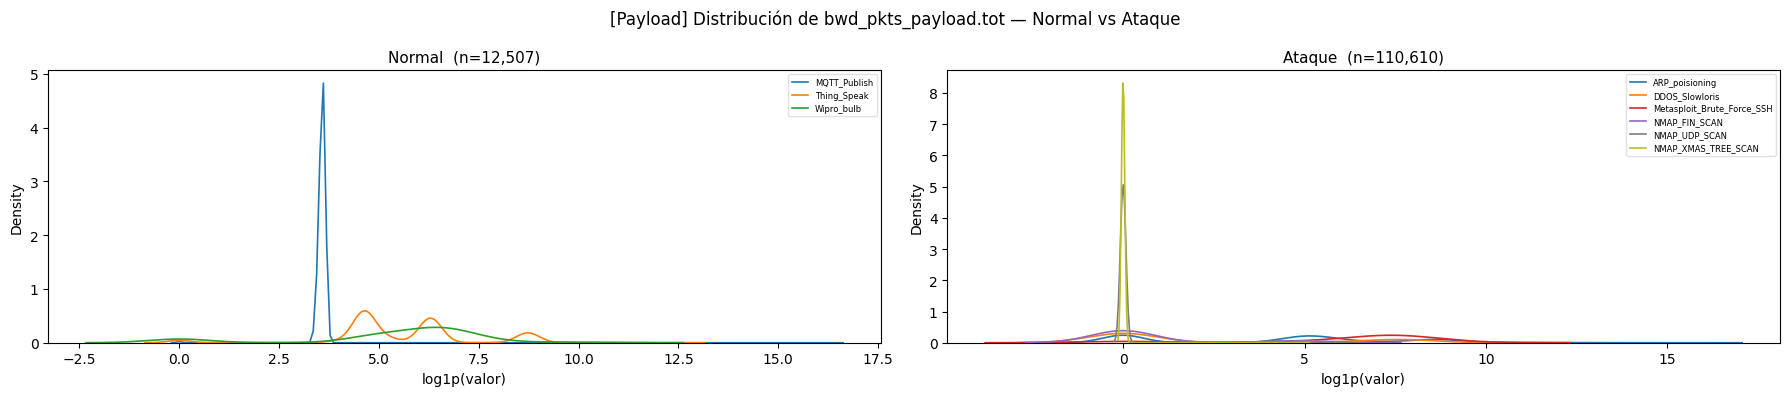

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


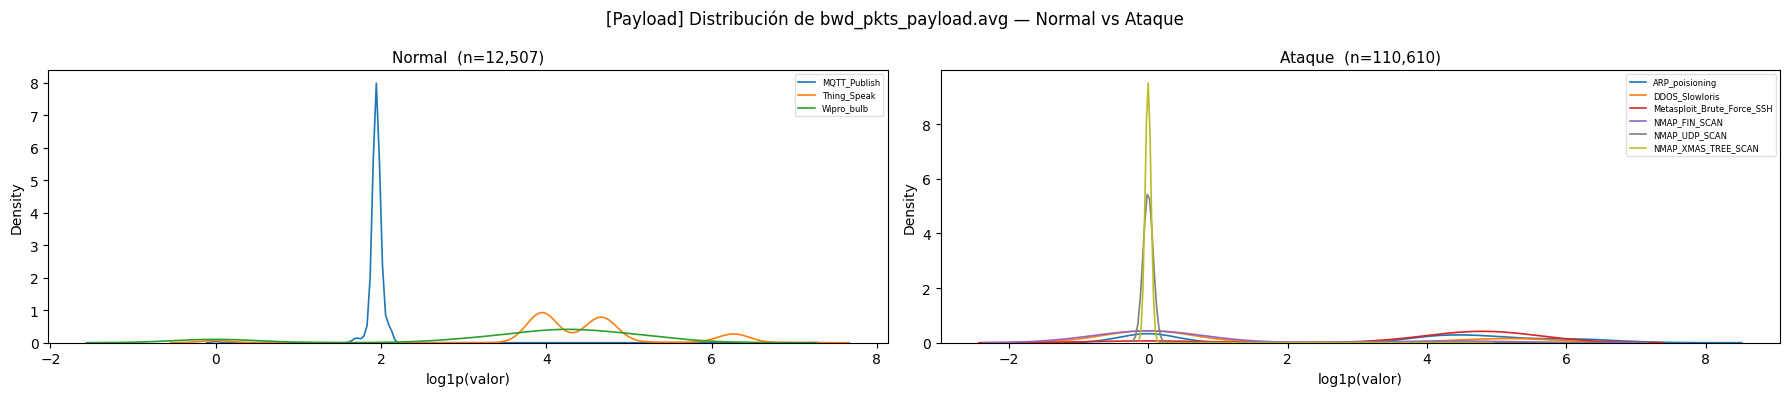

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


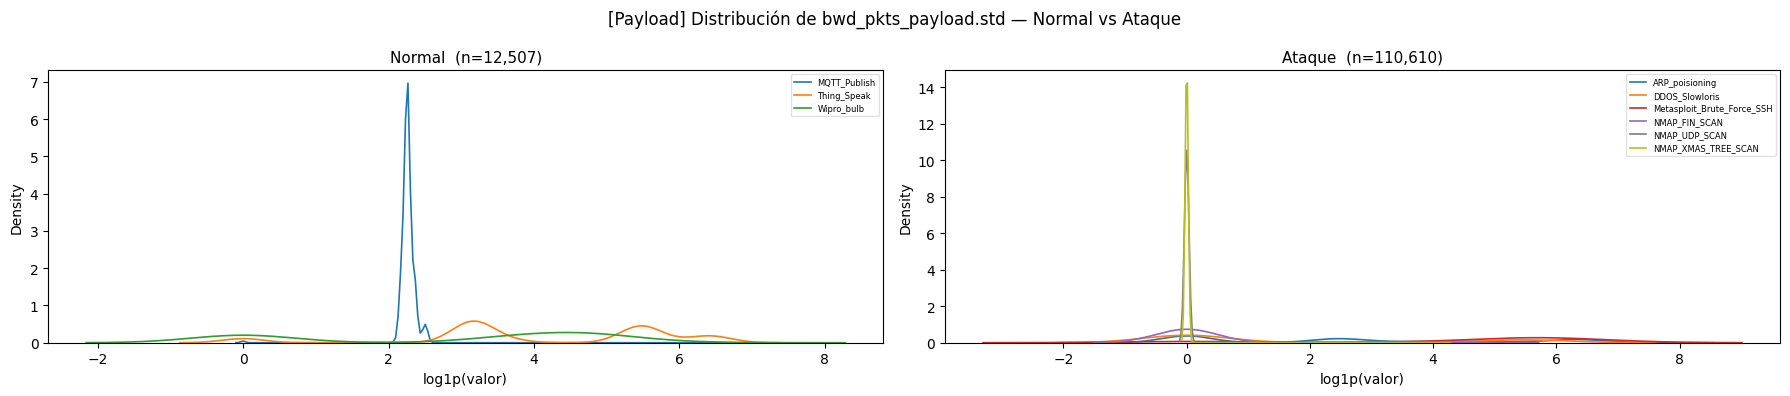

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


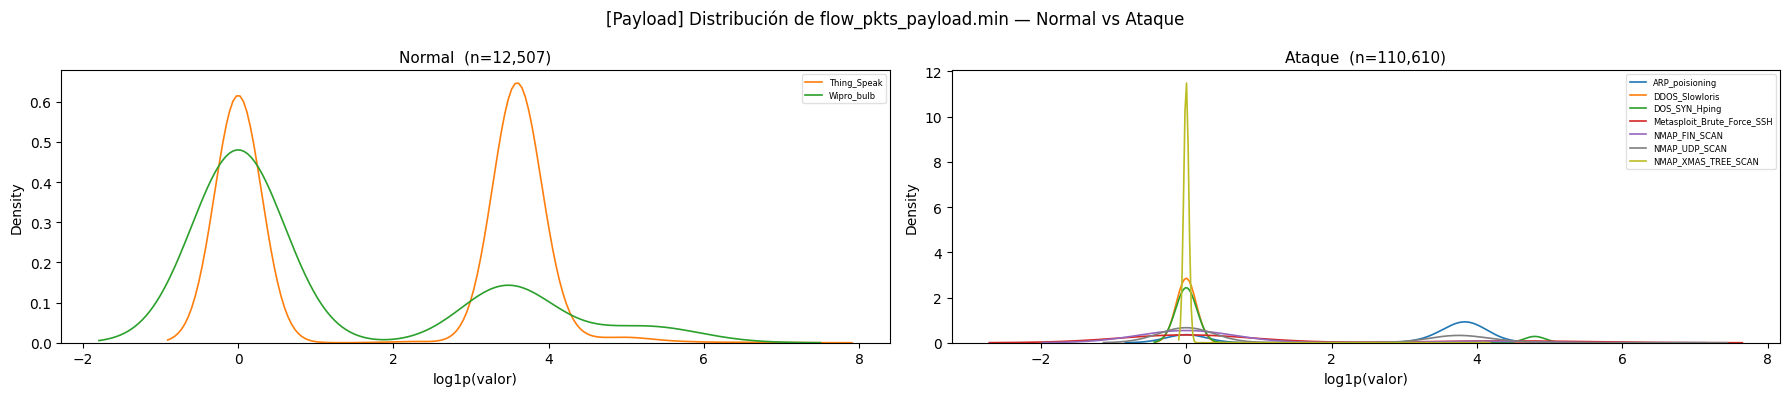

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


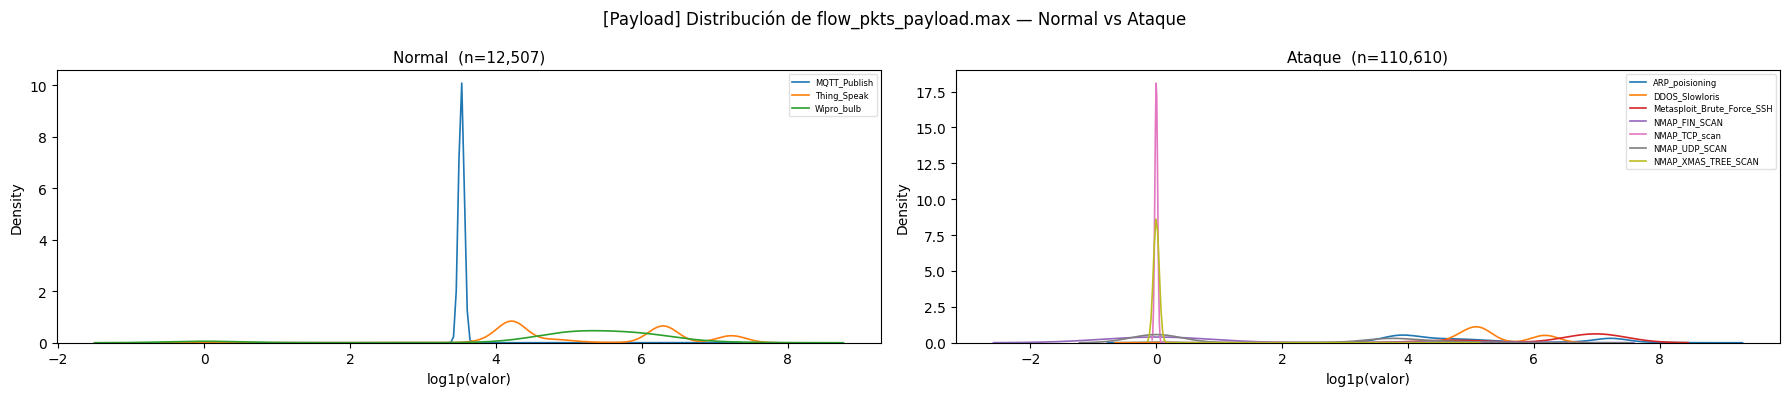

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


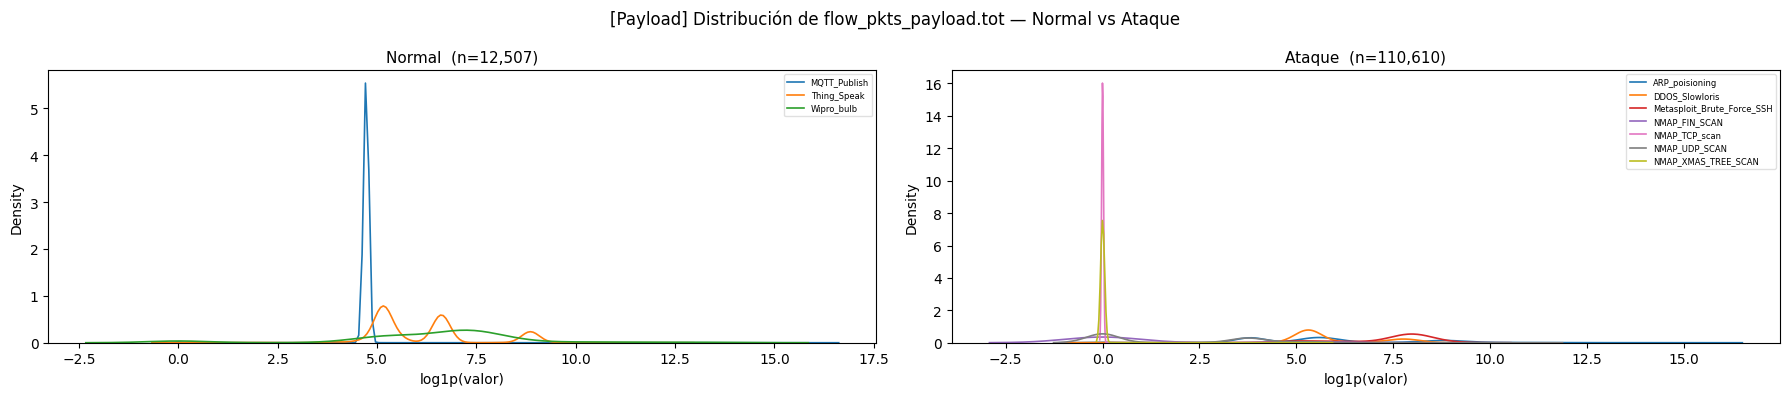

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


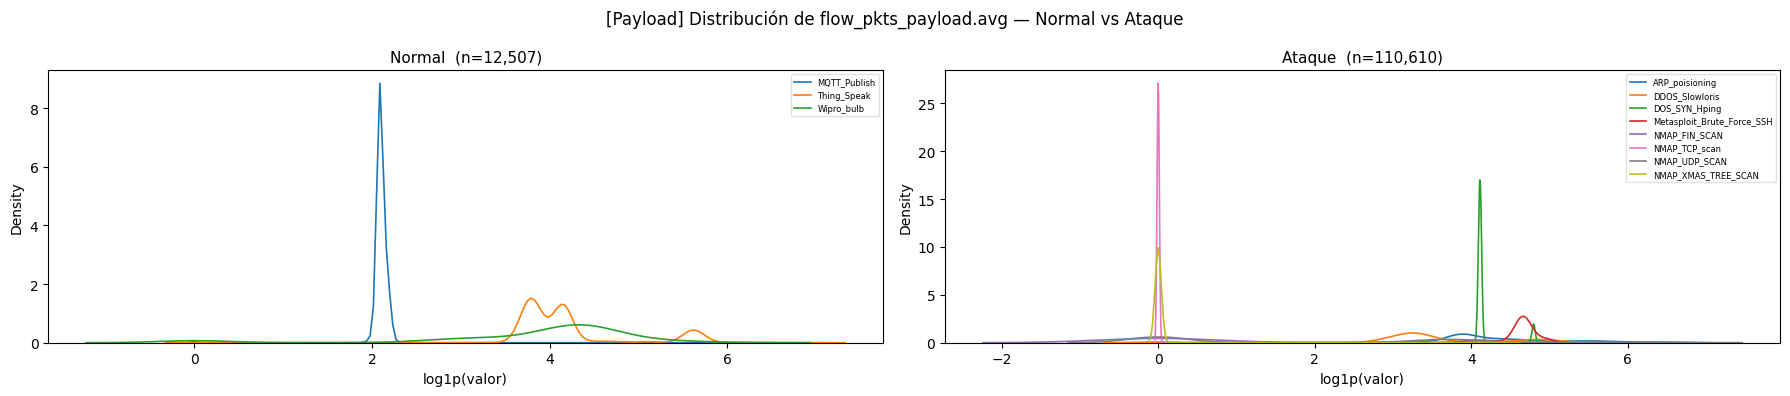

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


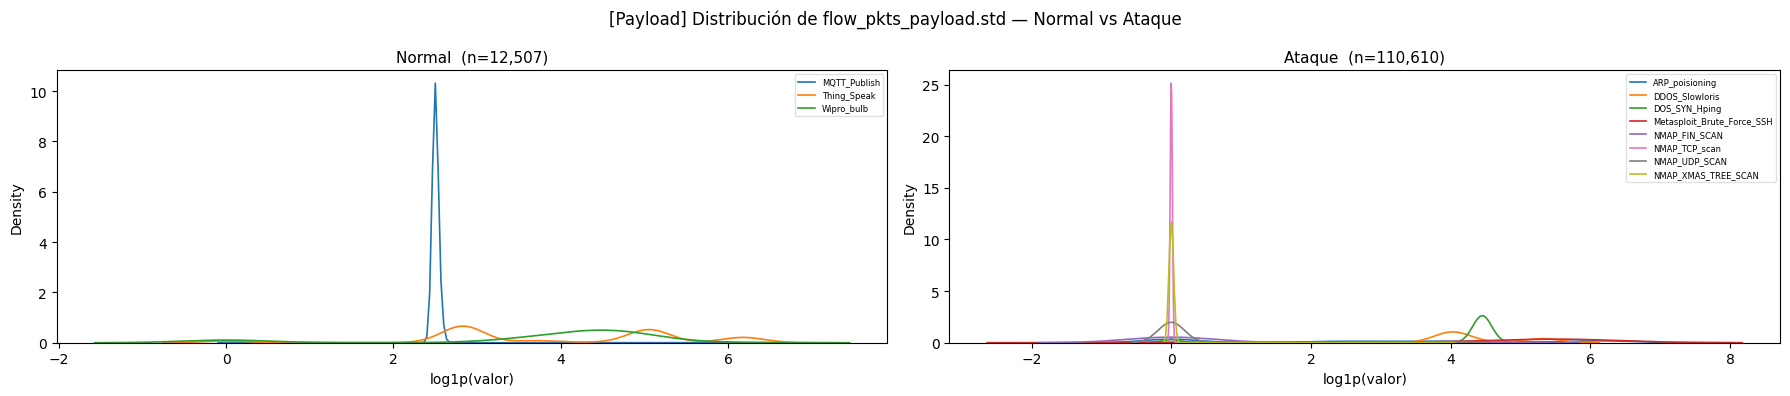

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


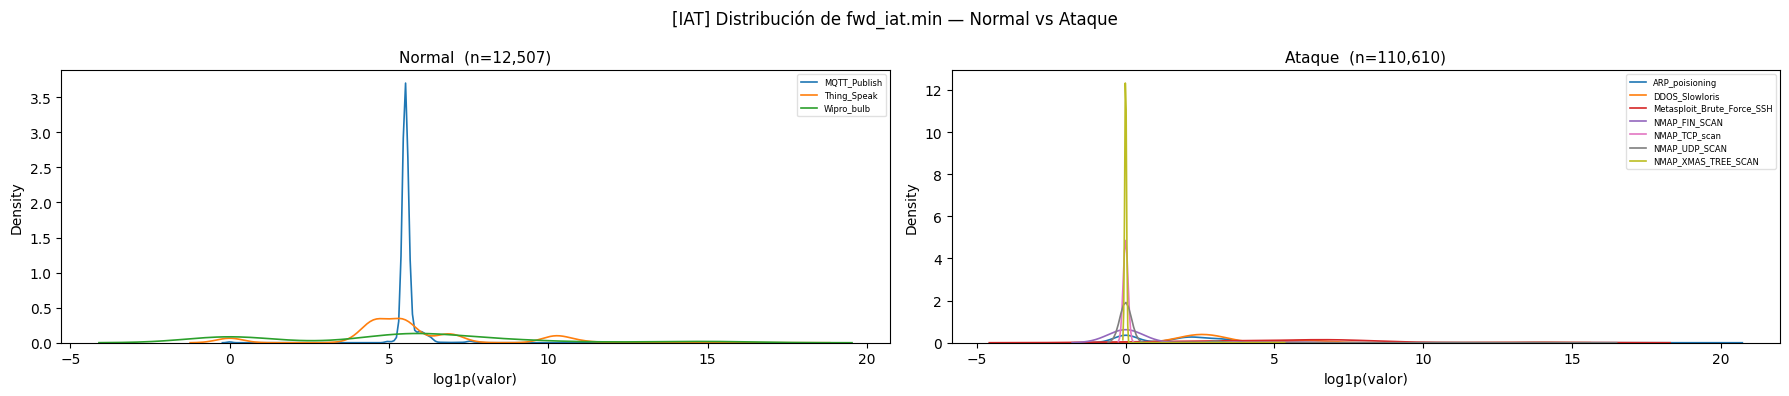

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


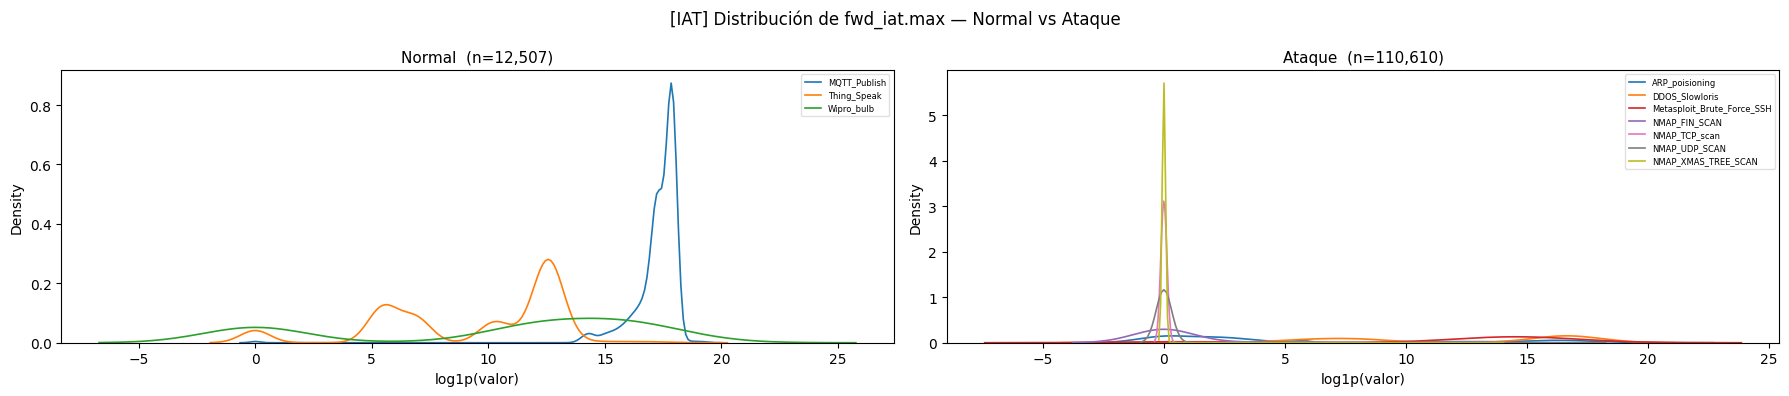

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


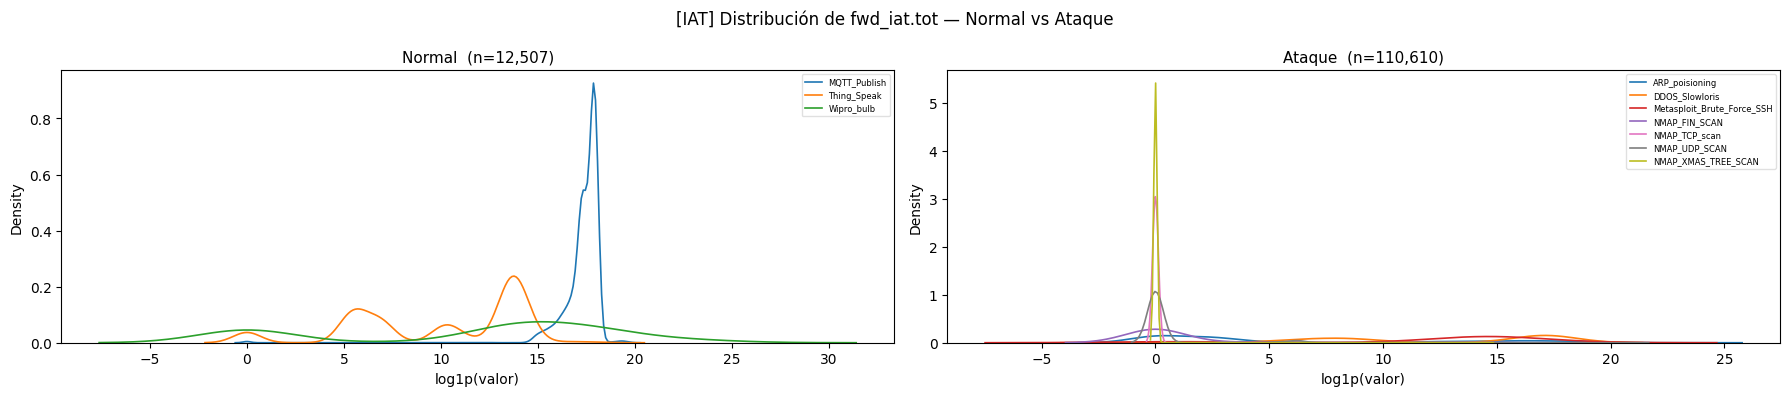

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


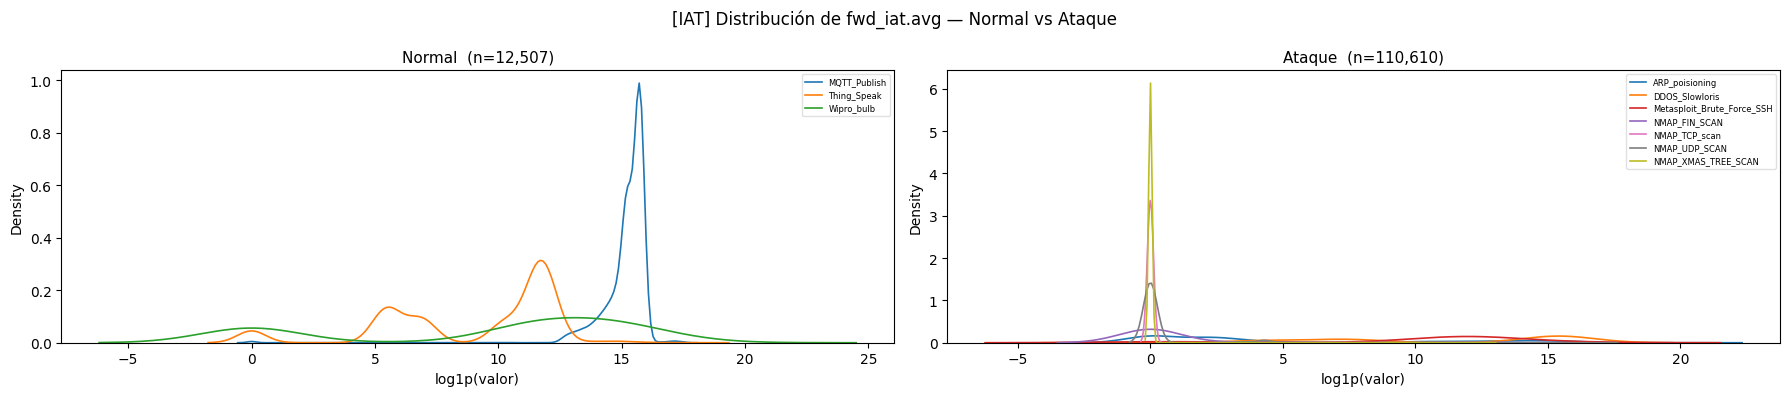

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


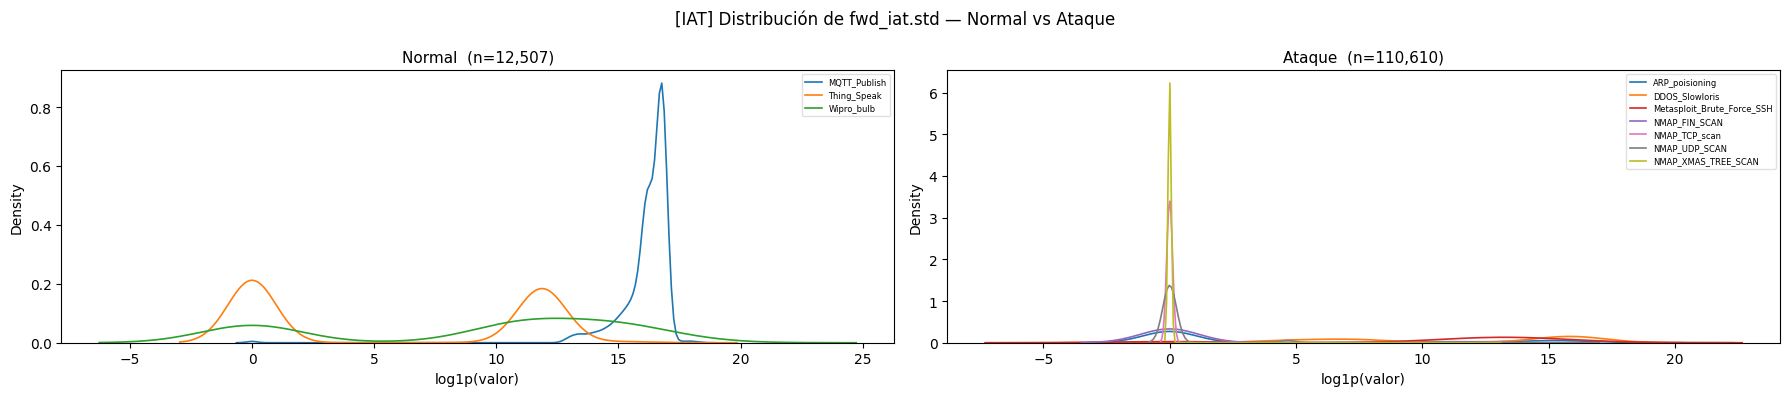

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


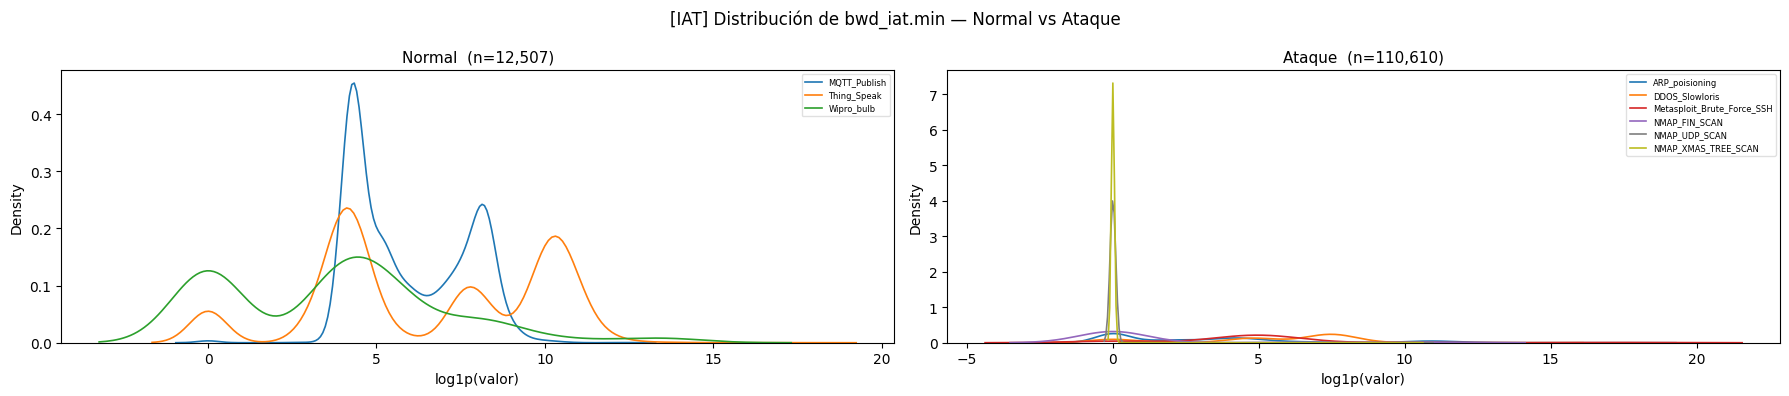

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


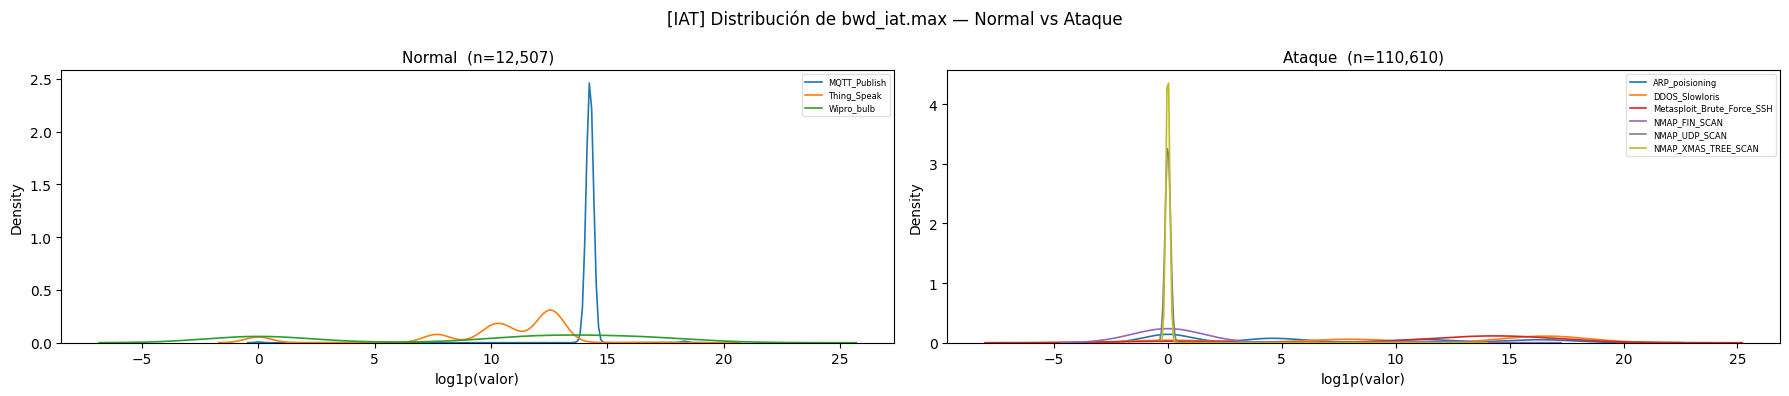

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


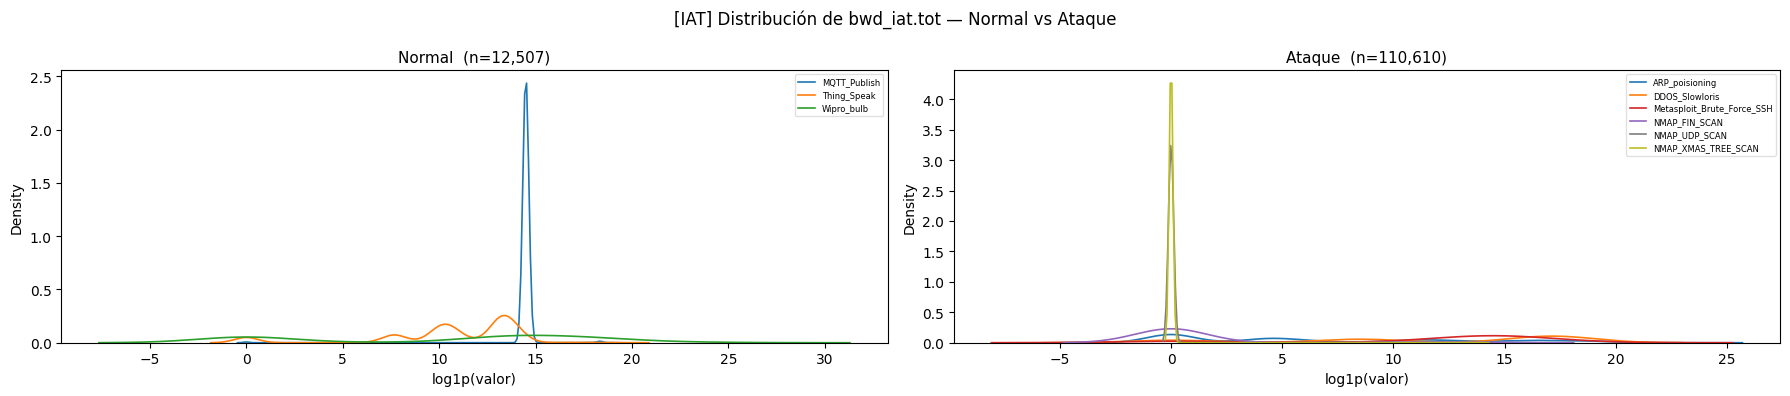

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


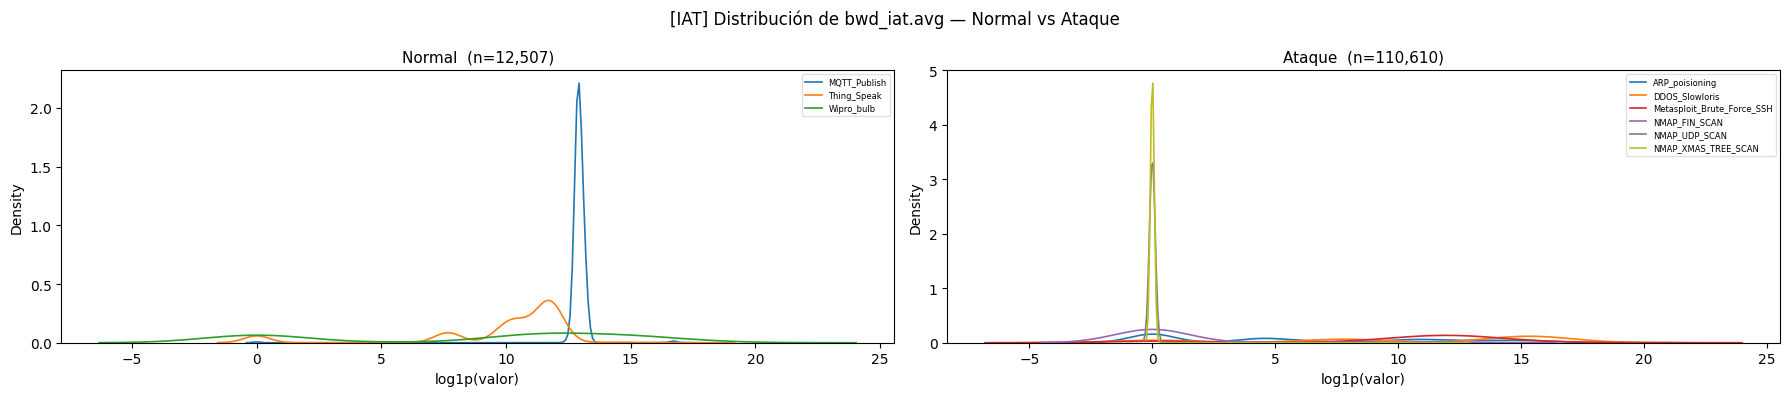

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


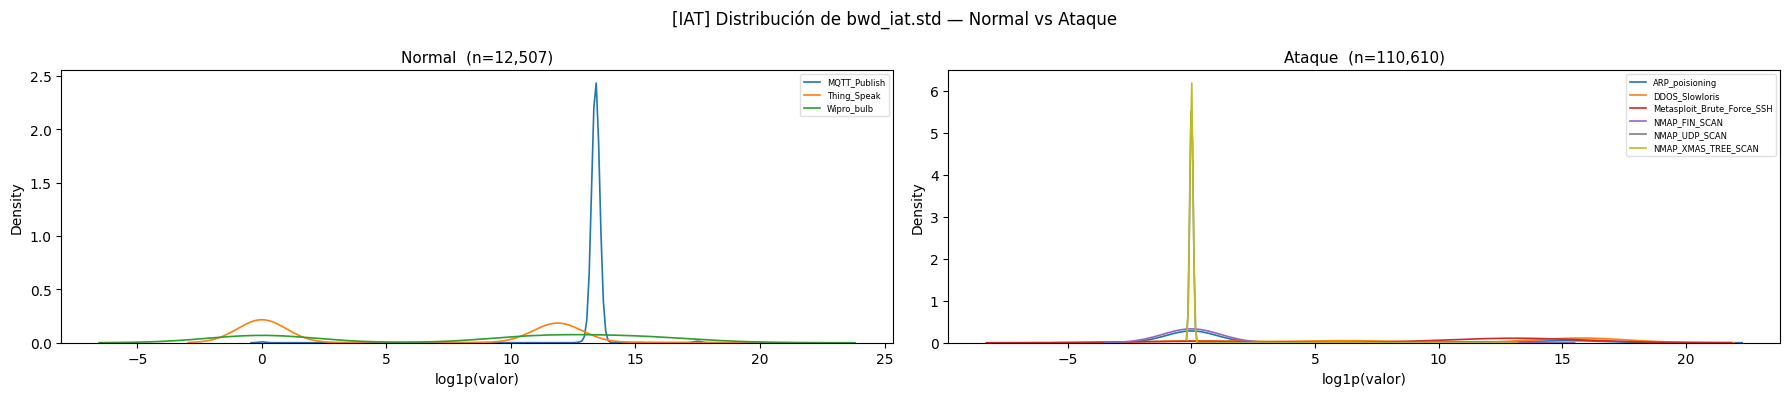

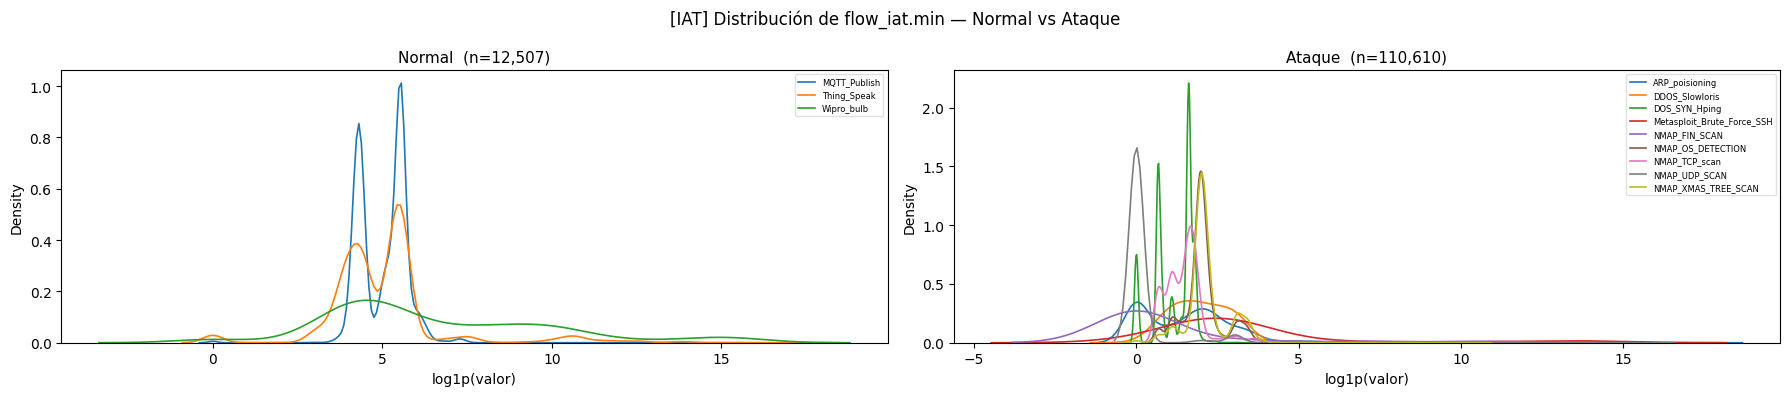

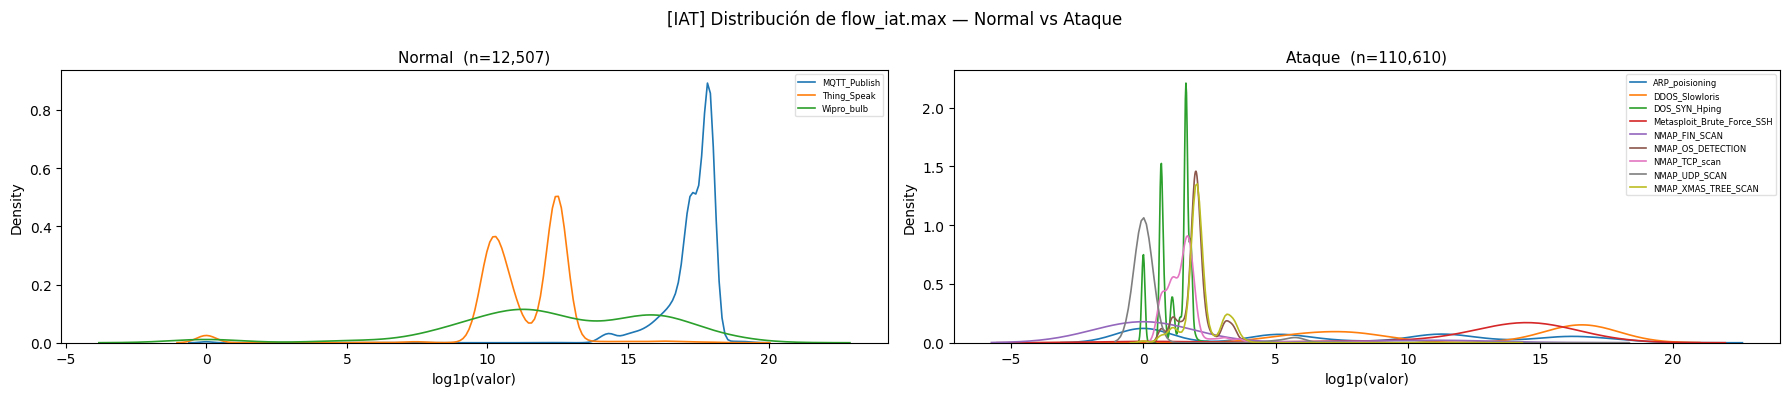

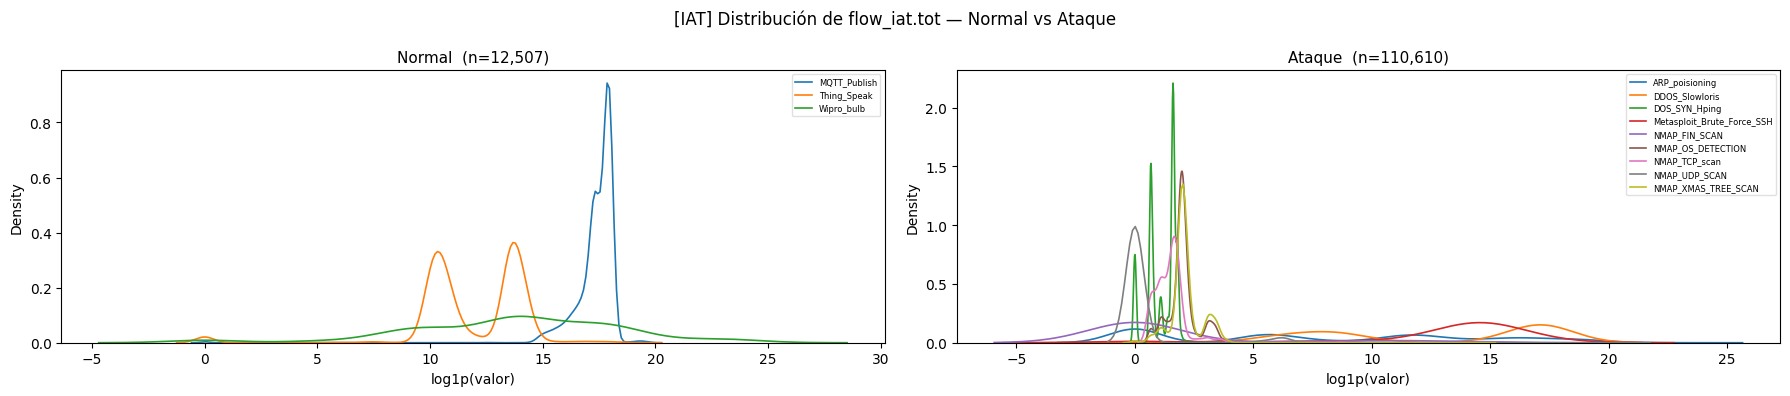

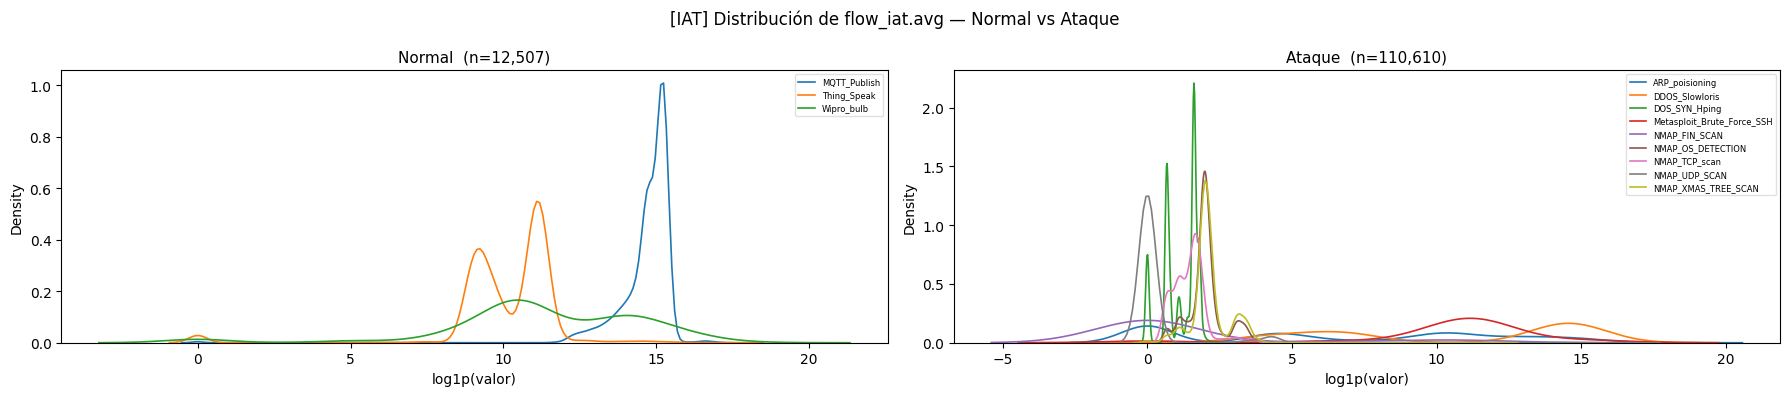

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_13880\3356837059.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)


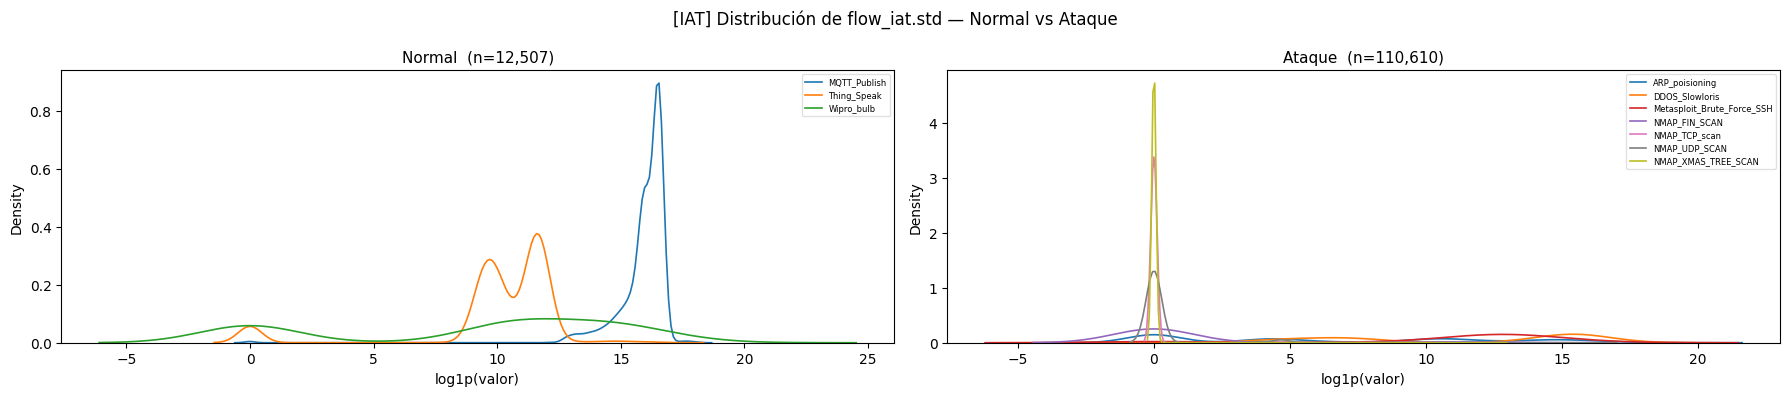

In [7]:
ataque_types = sorted(df[~df['Attack_type'].isin(normal_types)]['Attack_type'].unique())
                                
for nombre_grupo, lista_cols in [('Payload', payload_cols), ('IAT', iat_cols)]:
    for col in lista_cols:
        fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey=False)
        for ax, (grupo, etiquetas) in zip(axes, [('Normal', normal_types), ('Ataque', ataque_types)]):
            for etiqueta in etiquetas:
                vals = np.log1p(df[df['Attack_type'] == etiqueta][col].clip(lower=0))
                if len(vals) > 0:
                    sns.kdeplot(vals, ax=ax, label=etiqueta, fill=False, linewidth=1.2)
            ax.set_title(f'{grupo}  (n={len(df[df["traffic"]==grupo]):,})', fontsize=11)
            ax.set_xlabel('log1p(valor)')
            ax.legend(fontsize=6, loc='upper right', framealpha=0.6)
        plt.suptitle(f'[{nombre_grupo}] Distribución de {col} — Normal vs Ataque', fontsize=12)
        plt.tight_layout()
        plt.show()

## Sección 3 — Boxplots

### 3.1 Boxplots IAT — Normal vs Ataque

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\4183914677.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\4183914677.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\4183914677.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\4183914677.py:11: Future

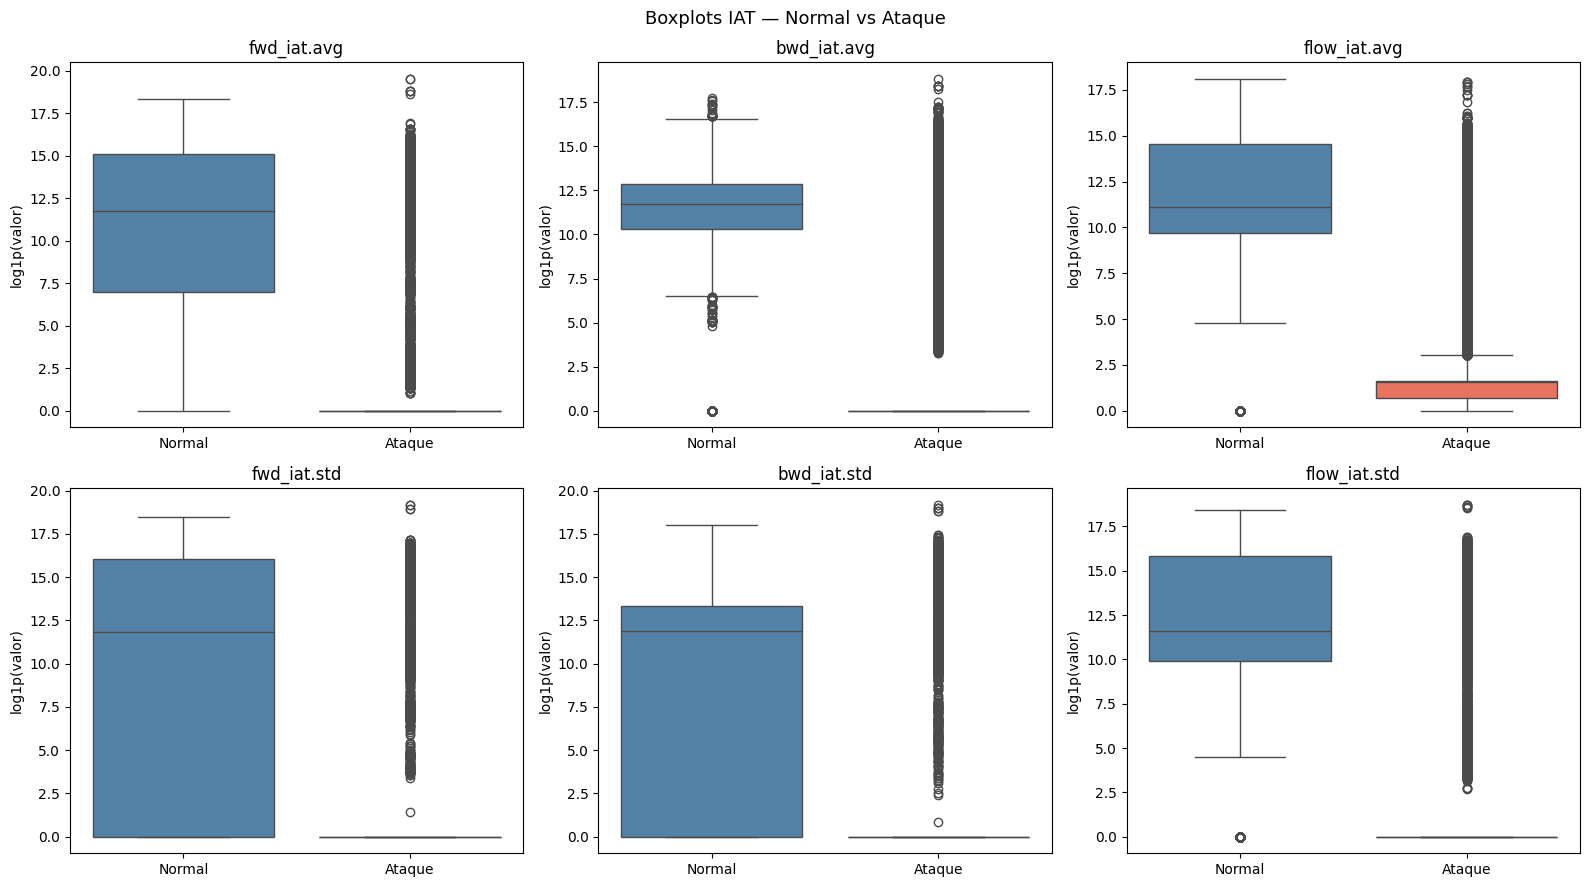

In [48]:
key_iat = ['fwd_iat.avg', 'bwd_iat.avg', 'flow_iat.avg',
           'fwd_iat.std', 'bwd_iat.std', 'flow_iat.std']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_iat):
    ax = axes[i]
    plot_df = df[['traffic', col]].copy()
    plot_df[col] = np.log1p(plot_df[col].clip(lower=0))
    sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
                palette=palette_binary, order=['Normal', 'Ataque'])
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('log1p(valor)')

plt.suptitle('Boxplots IAT — Normal vs Ataque', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 Boxplots payload — Normal vs Ataque

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1184813758.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1184813758.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1184813758.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1184813758.py:11: Future

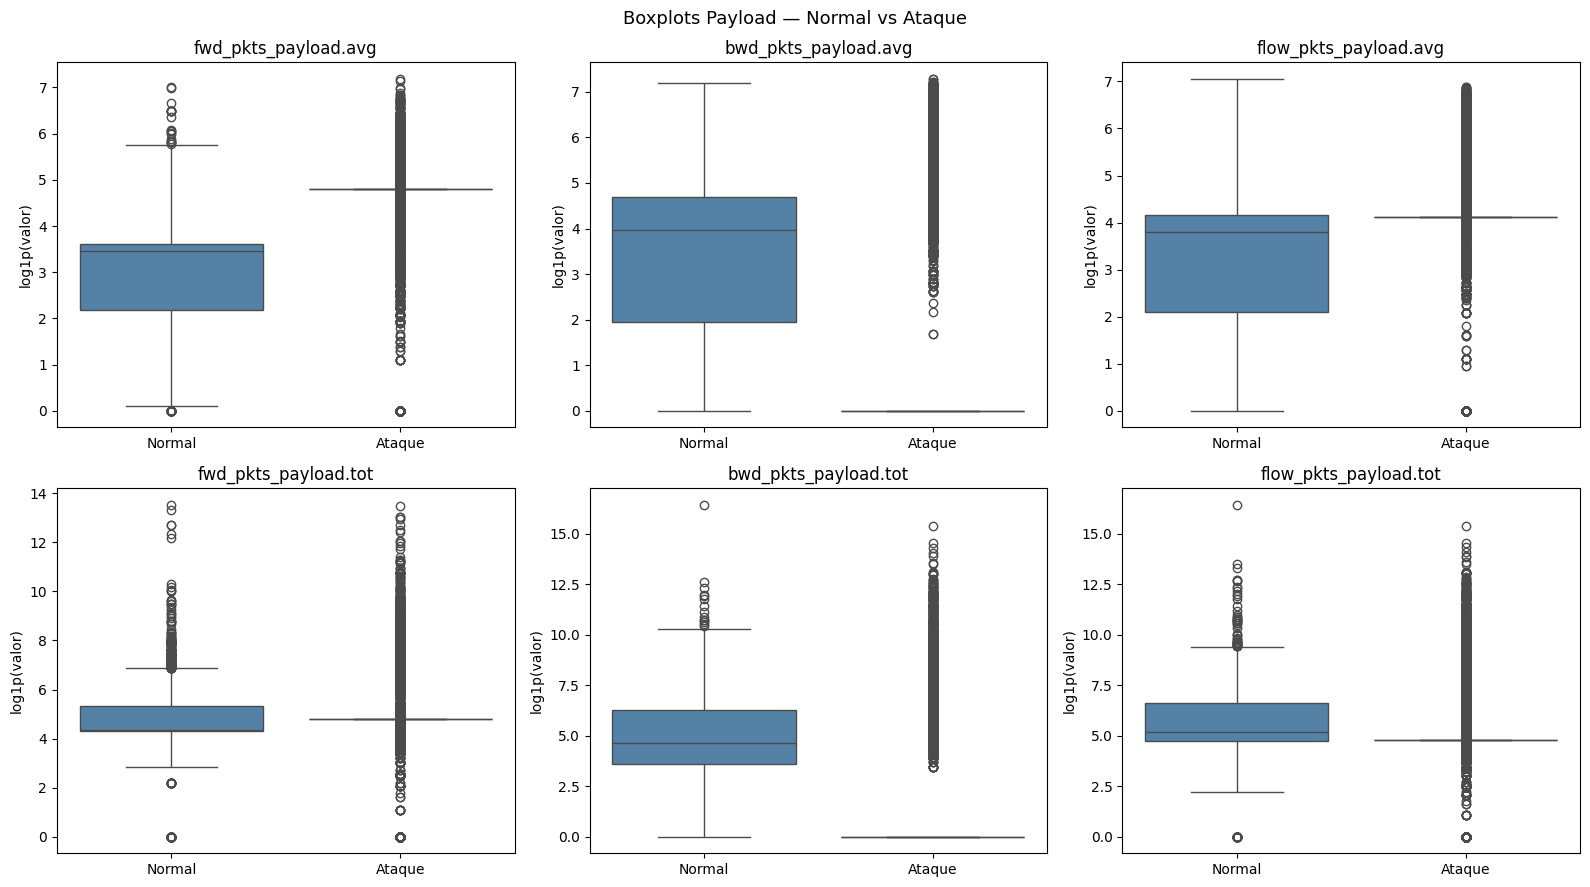

In [49]:
key_payload = ['fwd_pkts_payload.avg', 'bwd_pkts_payload.avg', 'flow_pkts_payload.avg',
               'fwd_pkts_payload.tot', 'bwd_pkts_payload.tot', 'flow_pkts_payload.tot']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_payload):
    ax = axes[i]
    plot_df = df[['traffic', col]].copy()
    plot_df[col] = np.log1p(plot_df[col].clip(lower=0))
    sns.boxplot(data=plot_df, x='traffic', y=col, ax=ax,
                palette=palette_binary, order=['Normal', 'Ataque'])
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('log1p(valor)')

plt.suptitle('Boxplots Payload — Normal vs Ataque', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Boxplots IAT y payload — por tipo de ataque (vista granular)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1019178484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Attack_type', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1019178484.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=5)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1019178484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Attack_type', y=col, ax=ax,
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1019178484.py:11: UserWarning: set_ticklabels() 

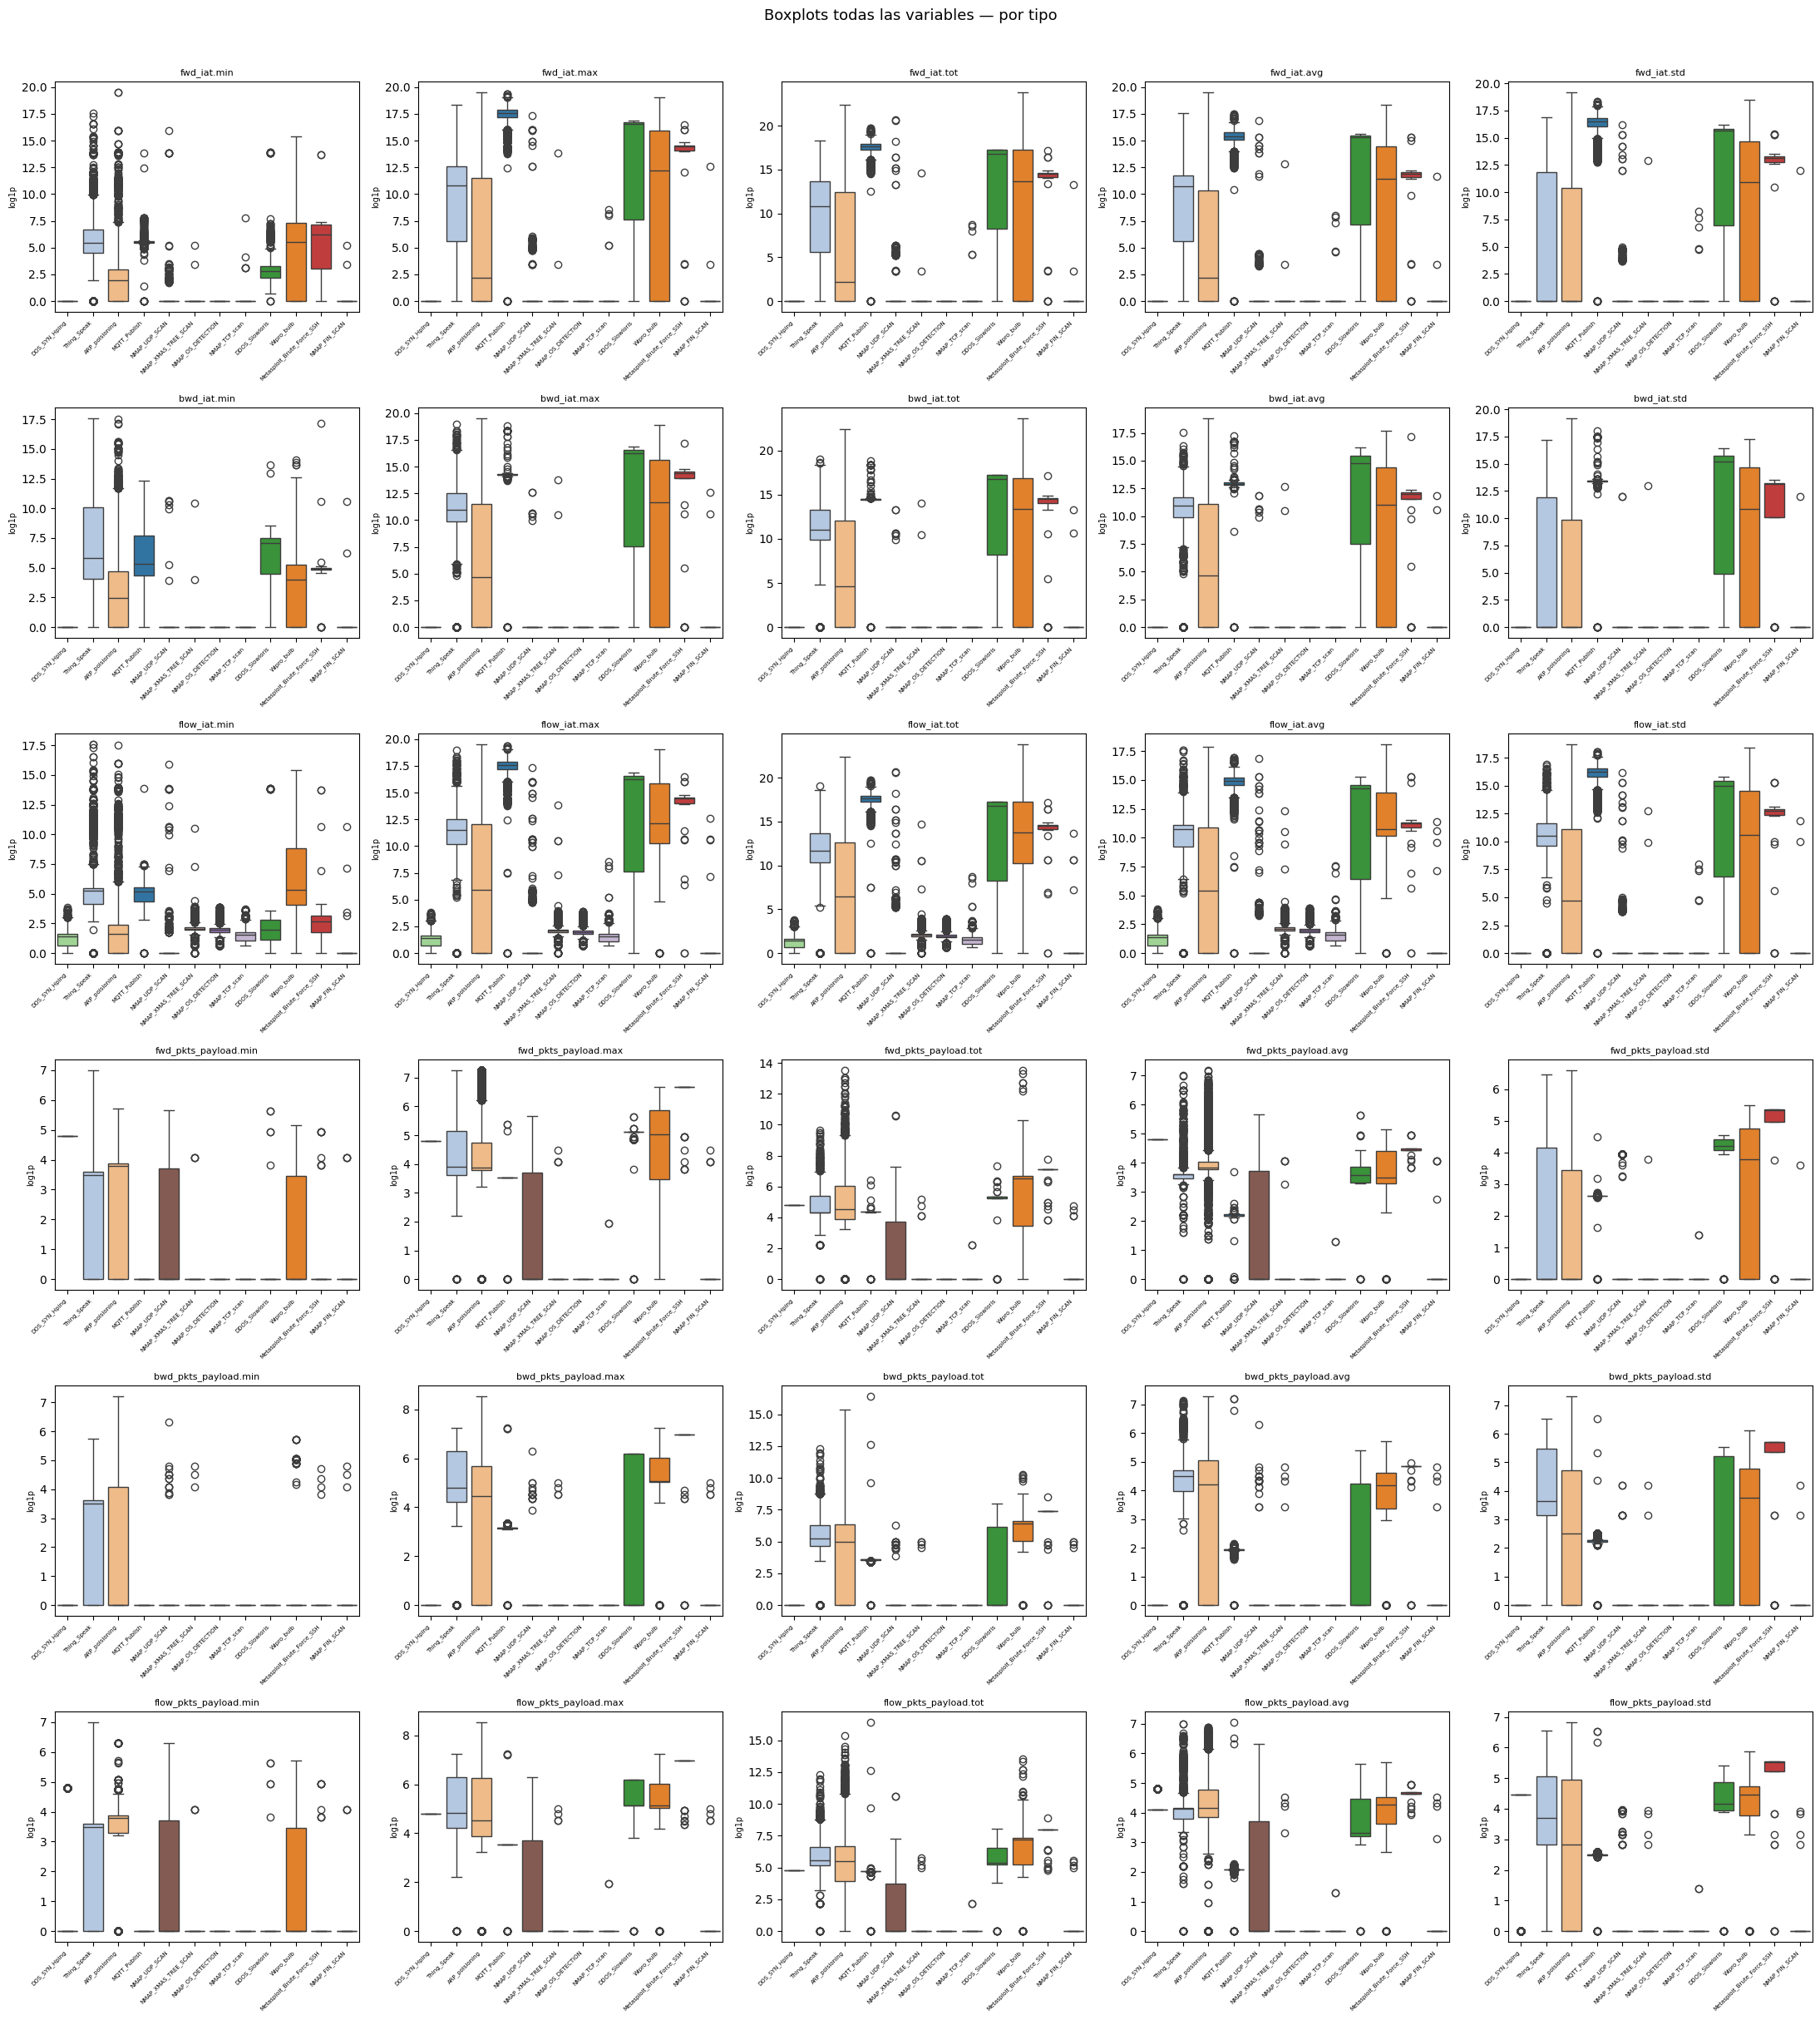

In [50]:
fig, axes = plt.subplots(6, 5, figsize=(22, 24))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    plot_df = df[['Attack_type', col]].copy()
    plot_df[col] = np.log1p(plot_df[col].clip(lower=0))
    sns.boxplot(data=plot_df, x='Attack_type', y=col, ax=ax,
                palette=palette_tipo, order=counts.index)
    ax.set_title(col, fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=5)
    ax.set_ylabel('log1p', fontsize=7)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots todas las variables — por tipo', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Sección 4 — Detección de outliers

### 4.1 Porcentaje de outliers por variable (método IQR)

In [21]:
def outlier_pct(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    mask = (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)
    return mask.mean() * 100

outlier_global  = df[all_cols].apply(outlier_pct).rename('% global')
outlier_normal  = df[df['traffic'] == 'Normal'][all_cols].apply(outlier_pct).rename('% en Normal')
outlier_ataque  = df[df['traffic'] == 'Ataque'][all_cols].apply(outlier_pct).rename('% en Ataque')

pd.concat([outlier_global, outlier_normal, outlier_ataque], axis=1).round(2)\
  .sort_values('% global', ascending=False)

,% global,% en Normal,% en Ataque
flow_pkts_payload.avg,30.96,9.75,23.15
fwd_pkts_payload.avg,23.11,2.05,14.42
fwd_pkts_payload.max,23.11,8.99,14.42
fwd_pkts_payload.tot,23.11,10.45,14.42
fwd_pkts_payload.min,23.11,0.99,14.42
flow_pkts_payload.tot,23.11,9.46,14.42
flow_pkts_payload.max,22.92,8.83,14.36
flow_pkts_payload.min,16.95,1.08,14.90
flow_iat.avg,15.58,0.45,6.61
flow_iat.tot,15.58,0.54,6.61


### 4.2 Ritmo vs tamaño — ¿dónde se ubica cada tipo?

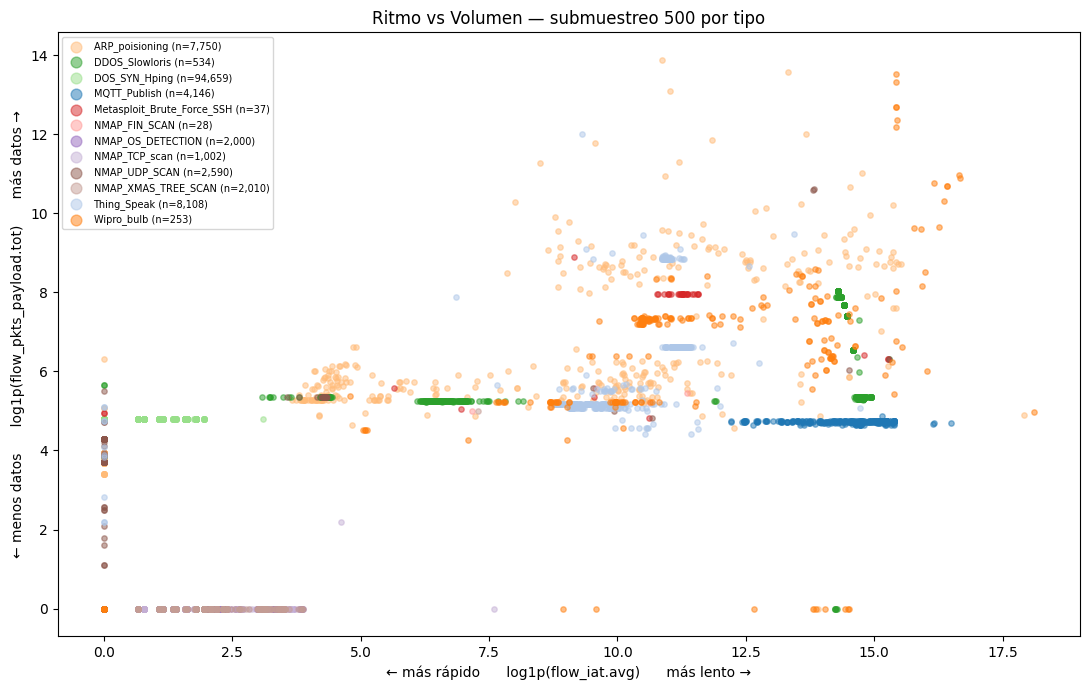

In [52]:
n_sample = 500
frames = []
for t in df['Attack_type'].unique():
    grp = df[df['Attack_type'] == t]
    frames.append(grp.sample(min(len(grp), n_sample), random_state=42))
df_plot = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 7))
for attack, grp in df_plot.groupby('Attack_type'):
    ax.scatter(
        np.log1p(grp['flow_iat.avg'].clip(lower=0)),
        np.log1p(grp['flow_pkts_payload.tot'].clip(lower=0)),
        alpha=0.5, s=15,
        label=f'{attack} (n={counts[attack]:,})',
        color=palette_tipo[attack]
    )

ax.set_xlabel('← más rápido      log1p(flow_iat.avg)      más lento →')
ax.set_ylabel('← menos datos      log1p(flow_pkts_payload.tot)      más datos →')
ax.set_title('Ritmo vs Volumen — submuestreo 500 por tipo')
ax.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

## Sección 5 — ¿Hay variables que miden lo mismo?

### 5.1 Correlación entre variables IAT

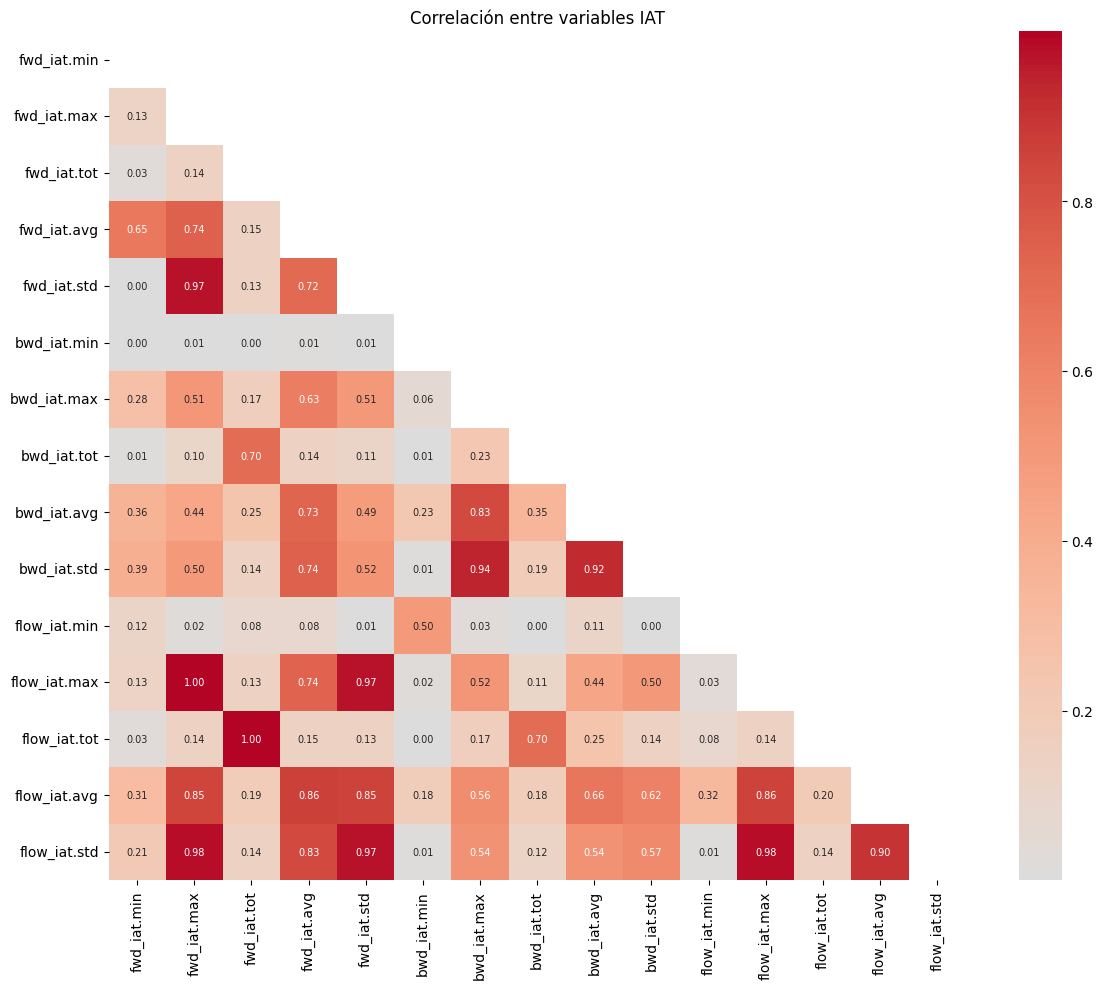

In [53]:
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones(15, dtype=bool))
sns.heatmap(df[iat_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlación entre variables IAT')
plt.tight_layout()
plt.show()

### 5.2 Correlación entre variables payload

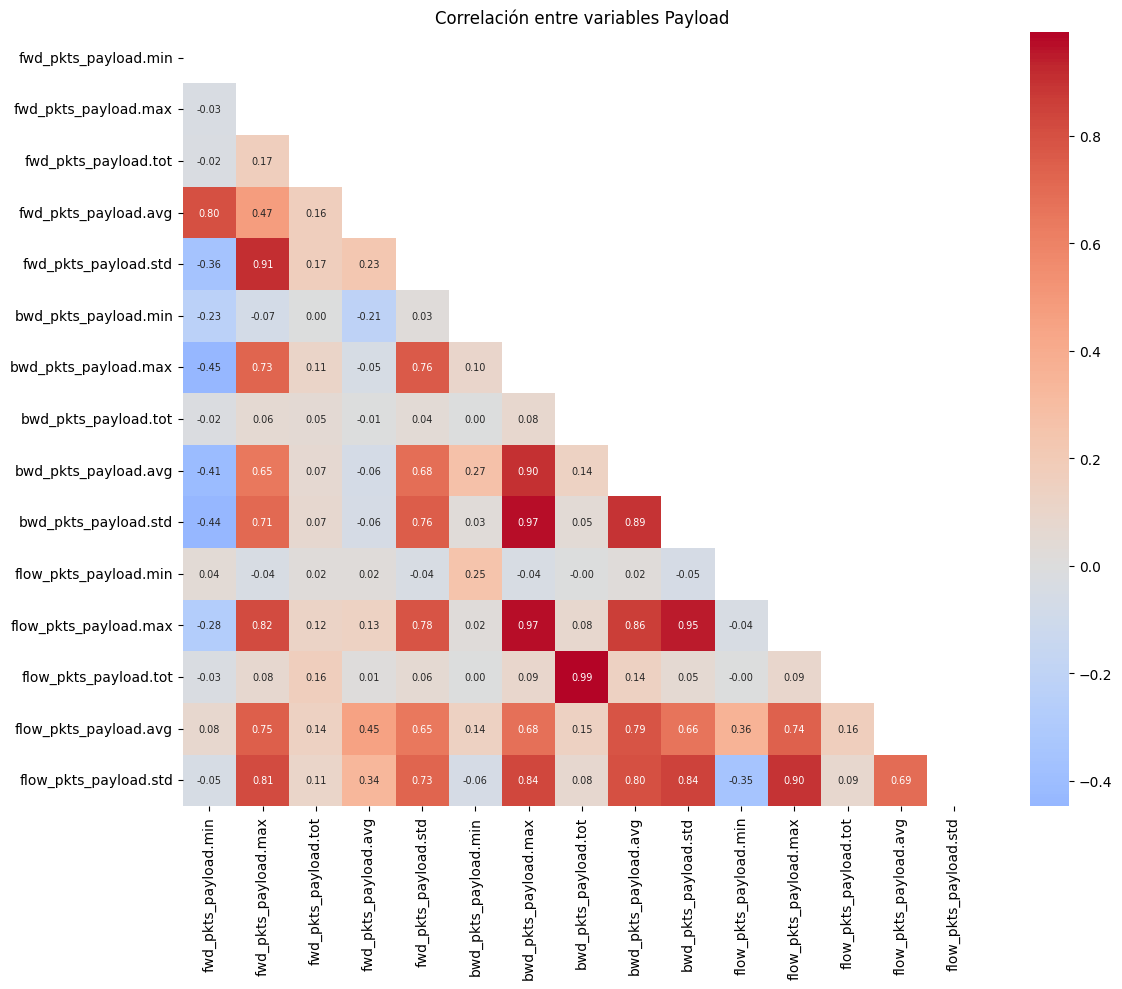

In [54]:
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones(15, dtype=bool))
sns.heatmap(df[payload_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlación entre variables Payload')
plt.tight_layout()
plt.show()

### 5.3 Pares con correlación > 0.9

In [55]:
corr_abs = df[all_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr = (
    upper.stack().reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'correlacion'})
    .query('correlacion > 0.9')
    .sort_values('correlacion', ascending=False)
)
print(high_corr.to_string(index=False))

                var1                  var2  correlacion
         fwd_iat.tot          flow_iat.tot     0.999719
         fwd_iat.max          flow_iat.max     0.996647
bwd_pkts_payload.tot flow_pkts_payload.tot     0.993704
        flow_iat.max          flow_iat.std     0.981454
         fwd_iat.max          flow_iat.std     0.980388
bwd_pkts_payload.max  bwd_pkts_payload.std     0.973975
         fwd_iat.max           fwd_iat.std     0.972222
bwd_pkts_payload.max flow_pkts_payload.max     0.971904
         fwd_iat.std          flow_iat.std     0.971838
         fwd_iat.std          flow_iat.max     0.968917
bwd_pkts_payload.std flow_pkts_payload.max     0.945337
         bwd_iat.max           bwd_iat.std     0.938798
         bwd_iat.avg           bwd_iat.std     0.922789
fwd_pkts_payload.max  fwd_pkts_payload.std     0.907555
        flow_iat.avg          flow_iat.std     0.903189


## Sección 6 — ¿Hay tráfico automatizado?

### 6.1 ¿Qué porcentaje de flujos tiene IAT completamente constante?

In [22]:
threshold = 1e-3
std_iat_cols     = ['fwd_iat.std', 'bwd_iat.std', 'flow_iat.std']
std_payload_cols = ['fwd_pkts_payload.std', 'bwd_pkts_payload.std', 'flow_pkts_payload.std']

rows = []
for col in std_iat_cols + std_payload_cols:
    for traffic, grp in df.groupby('traffic'):
        pct = (grp[col] < threshold).mean() * 100
        rows.append({'variable': col, 'grupo': traffic, '% std ≈ 0': round(pct, 2)})

pd.DataFrame(rows).pivot(index='variable', columns='grupo', values='% std ≈ 0')

grupo,Ataque,Normal
variable,,
bwd_iat.std,97.70,35.33
bwd_pkts_payload.std,95.49,6.02
flow_iat.std,94.82,5.11
flow_pkts_payload.std,17.93,3.22
fwd_iat.std,97.37,34.72
fwd_pkts_payload.std,97.49,35.20


### 6.2 Detalle por tipo de ataque

In [57]:
for col in std_iat_cols + std_payload_cols:
    result = (
        df.groupby('Attack_type')[col]
        .apply(lambda x: (x < threshold).mean() * 100)
        .rename('% std ≈ 0')
        .sort_values(ascending=False)
    )
    print(f'\n{col}')
    print(result.round(2).to_string())


fwd_iat.std
Attack_type
DOS_SYN_Hping                 100.00
NMAP_OS_DETECTION             100.00
NMAP_XMAS_TREE_SCAN            99.95
NMAP_TCP_scan                  99.50
NMAP_FIN_SCAN                  96.43
NMAP_UDP_SCAN                  94.32
ARP_poisioning                 71.66
Thing_Speak                    52.48
Wipro_bulb                     30.83
Metasploit_Brute_Force_SSH     16.22
DDOS_Slowloris                  0.56
MQTT_Publish                    0.24

bwd_iat.std
Attack_type
DOS_SYN_Hping                 100.00
NMAP_TCP_scan                 100.00
NMAP_OS_DETECTION             100.00
NMAP_XMAS_TREE_SCAN            99.95
NMAP_UDP_SCAN                  99.92
NMAP_FIN_SCAN                  96.43
ARP_poisioning                 73.10
Thing_Speak                    53.19
Wipro_bulb                     37.55
Metasploit_Brute_Force_SSH     24.32
DDOS_Slowloris                 19.66
MQTT_Publish                    0.27

flow_iat.std
Attack_type
DOS_SYN_Hping                 100.00

In [20]:
for col in std_iat_cols + std_payload_cols:
    result = (
        df.groupby('Attack_type')[col]
        .apply(lambda x: (x < threshold).mean() * 100)
        .rename('% std ≈ 0')
        .sort_values(ascending=False)
    )
    lines = f'\n{col}\n' + result.round(2).to_string() + '\n'
    print(lines)
    with open('std_results.txt', 'a') as f:
        f.write(lines)


fwd_iat.std
Attack_type
DOS_SYN_Hping                 100.00
NMAP_OS_DETECTION             100.00
NMAP_XMAS_TREE_SCAN            99.95
NMAP_TCP_scan                  99.50
NMAP_FIN_SCAN                  96.43
NMAP_UDP_SCAN                  94.32
ARP_poisioning                 71.66
Thing_Speak                    52.48
Wipro_bulb                     30.83
Metasploit_Brute_Force_SSH     16.22
DDOS_Slowloris                  0.56
MQTT_Publish                    0.24


bwd_iat.std
Attack_type
DOS_SYN_Hping                 100.00
NMAP_TCP_scan                 100.00
NMAP_OS_DETECTION             100.00
NMAP_XMAS_TREE_SCAN            99.95
NMAP_UDP_SCAN                  99.92
NMAP_FIN_SCAN                  96.43
ARP_poisioning                 73.10
Thing_Speak                    53.19
Wipro_bulb                     37.55
Metasploit_Brute_Force_SSH     24.32
DDOS_Slowloris                 19.66
MQTT_Publish                    0.27


flow_iat.std
Attack_type
DOS_SYN_Hping                 100.

### 6.3 Violinplot de variabilidad — Normal vs Ataque

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1817984469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='traffic', y=col, ax=axes[i],
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1817984469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='traffic', y=col, ax=axes[i],
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\1817984469.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='traffic', y=col, ax=axes[i],
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15660\181

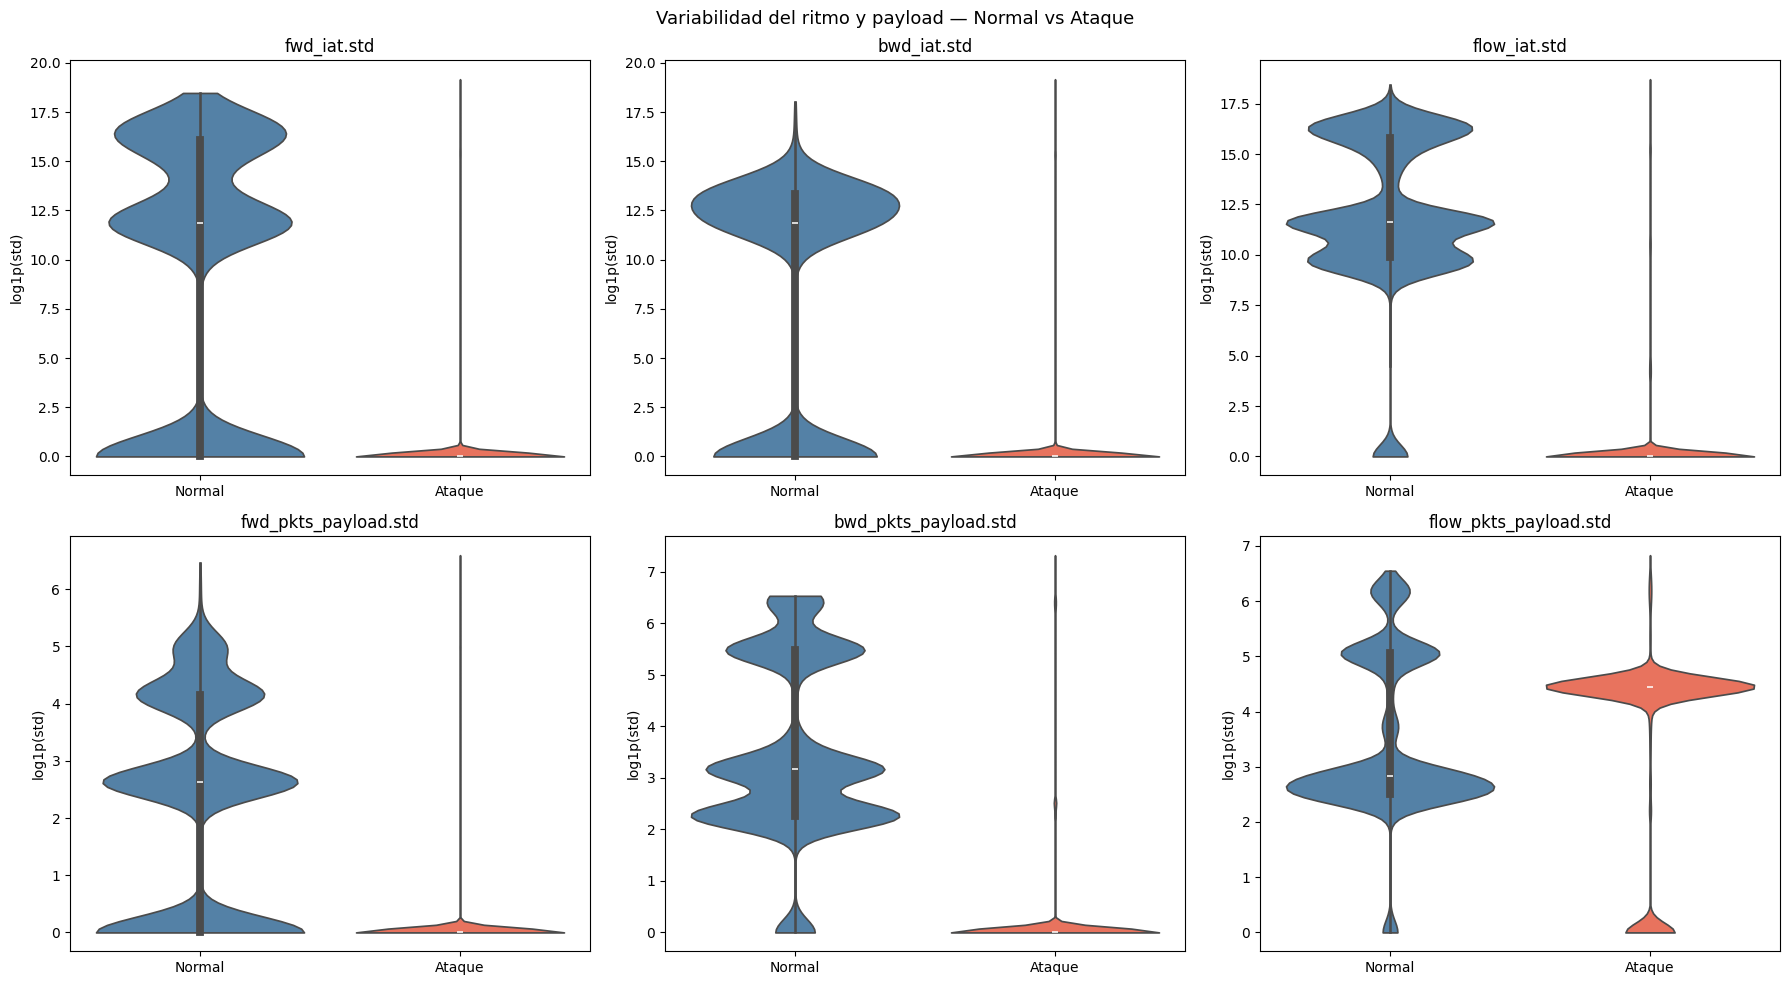

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(std_iat_cols + std_payload_cols):
    plot_df = df[['traffic', col]].copy()
    plot_df[col] = np.log1p(plot_df[col].clip(lower=0))
    sns.violinplot(data=plot_df, x='traffic', y=col, ax=axes[i],
                   palette=palette_binary, order=['Normal', 'Ataque'], cut=0)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('log1p(std)')

plt.suptitle('Variabilidad del ritmo y payload — Normal vs Ataque', fontsize=13)
plt.tight_layout()
plt.show()

## Sección 7 — Resumen y variables candidatas

### 7.1 Tabla de utilidad

In [60]:
## Una variable es útil si:
# 1. Tiene valores distintos entre Normal y Ataque (ratio alejado de 1).
# 2. No está dominada por ceros (pct_ceros < 50%).

med = df.groupby('traffic')[all_cols].median()
ratio = (med.loc['Ataque'] / med.loc['Normal'].replace(0, np.nan)).rename('ratio Ataque/Normal')
zero_pct = (df[all_cols] == 0).mean() * 100

summary_df = pd.DataFrame({
    'mediana Normal': med.loc['Normal'].round(2),
    'mediana Ataque': med.loc['Ataque'].round(2),
    'ratio Ataque/Normal': ratio.round(2),
    'pct_ceros': zero_pct.round(1),
})
summary_df['diferencia'] = (summary_df['ratio Ataque/Normal'] - 1).abs()
summary_df.sort_values('diferencia', ascending=False)

,mediana Normal,mediana Ataque,ratio Ataque/Normal,pct_ceros,diferencia
flow_pkts_payload.std,16.00,84.85,5.30,16.4,4.30
fwd_pkts_payload.avg,30.71,120.00,3.91,5.5,2.91
fwd_pkts_payload.max,36.00,120.00,3.33,5.5,2.33
fwd_iat.avg,124491.69,0.00,0.00,85.7,1.00
fwd_iat.std,138889.87,0.00,0.00,91.0,1.00
bwd_iat.min,198.13,0.00,0.00,86.1,1.00
bwd_iat.max,283788.92,0.00,0.00,86.1,1.00
bwd_iat.tot,597270.97,0.00,0.00,86.1,1.00
fwd_iat.min,240.80,0.00,0.00,85.7,1.00
fwd_iat.max,294732.09,0.00,0.00,85.7,1.00


### 7.2 Variables candidatas para el modelo

In [61]:
candidatas = summary_df[
    (summary_df['pct_ceros'] < 50) &
    (summary_df['diferencia'] > 1)
].sort_values('diferencia', ascending=False)[['ratio Ataque/Normal', 'pct_ceros']].reset_index()

candidatas.columns = ['variable', 'ratio Ataque/Normal', 'pct_ceros']
print(candidatas.to_string(index=False))

             variable  ratio Ataque/Normal  pct_ceros
flow_pkts_payload.std                 5.30       16.4
 fwd_pkts_payload.avg                 3.91        5.5
 fwd_pkts_payload.max                 3.33        5.5
